# 275. Figure 1: related proteins keep their H/P pattern in runs, so the seed length is a trade

Figure 1 of the kmerseek paper, in one H/P alphabet, `hp_lehninger2` (hydrophobic `AFGILMPVWY`,
polar `CDEHKNQRST`). It is the alphabet in which the running example, CED-9 against BCL2 at the
BH1 motif, has its longest same-class run (19 residues; 11 in `hp_thomas_dill2`, notebook 246),
and the one PRs 54 and 82 use for that pair.

* **Figure 1** (`figures/fig1.pdf`):
  **a** how kmerseek works, drawn from the output of `kmerseek pair` on CED-9 (P41958) against
  BCL2 (P10415) at k = 17;
  **b** Cohen's kappa by identity, H/P against the 20 amino acids, over Pfam seed pairs;
  **c** the share of Pfam seed pairs at 20-30% identity whose longest same-class run is at least
  k, against independent positions and shuffled pairs;
  **d** the seed-length trade: Pfam pairs that share a seed (top) and human proteins that share a
  seed with CED-9 (bottom), against k.
* **Supplementary figure** (`figures/figS_fig1_hp_thomas_dill2_pair_and_dotplots.pdf`): the two
  `hp_thomas_dill2` panels of the previous Figure 1 (one typical pair, RPIR_ECOLI against
  Y143_HAEIN; dot plots of LPOA_HAEIN against LPOA_VIBCH), kept and moved out.
* **Figure 3 draft** (`figures/fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct.pdf`): panel c
  with the real / predicted ratio and k\*, now in `hp_lehninger2`.

**Question.** How long are the stretches in which related proteins keep the H/P class of aligned
residues, and what does that mean for the k-mer length kmerseek seeds with?

**Decision rule.** The figure is drawn only if:
`kmerseek pair` gives one region from 3 shared 17-mers, CED-9 163-181 against BCL2 139-157
(1-based, inclusive); the 20-30% kappa matches the PR 53 table to 4 decimals; and PR 113's tables
give 0.473 and 19,647 at k = 12 and 0.100 and 5,597 at k = 18. If any differs, the notebook stops.

**Data.**

* `kmerseek pair` output, `data/fig1_ced9_bcl2/ced9_bcl2_hp_lehninger2_k17.pair.json`, made by
  `scripts/run_fig1_kmerseek_pair.sh` with kmerseek `main` at `00395d7`; the commit is in the
  `.provenance.txt` beside it. Sequences and BH motifs from UniProt release 2026_03, in the same
  folder.
* Pfam-A 38.2 seed pairs: notebook 230's per-pair table
  `/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet` and the aligned pairs
  `/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet`. Pairs with at least 50 aligned
  positions.
* Kappa per alphabet at 20-30% identity:
  `nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv`
  (PR 53), a check on the recomputed bin.
* Seed reach and the human proteome search: `tables/246_pfam_seed_pairs_reach.tsv` and
  `tables/246_human_proteome_search.tsv` from PR 113 (branch `olgabot/mismatch-seeds-246`,
  commit `d133c2a`), exact seeds only.
* k-mer sizes kmerseek tests per alphabet:
  `tables/274_ksizes_to_test_per_alphabet_human_swissprot.csv` from PR 101 (branch
  `olgabot/ksizes-per-alphabet-274`, commit `8bfba6c`).
* H/P classes: kmerseek `src/rust/alphabets.rs` at commit `00395d7` (kmerseek `main`).
* Swiss-Prot release 2026_03, `/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz`: residue
  counts for k\* and full sequences for the supplementary dot plots.
* `Pfam-A.seed.gz` (Pfam 38.2): searched for per-sequence secondary structure.

**Terms.**

* **H/P class**: hydrophobic (h) or polar (p).
* **Shared k-mer, or seed**: a run of k letters that both proteins contain, in the H/P letters.
* **Cohen's kappa**: agreement of the classes of aligned residues, corrected for chance,
  `(Pr(agree) - Pr(agree by chance)) / (1 - Pr(agree by chance))`, where `Pr(agree by chance)`
  comes from the two sequences' class shares. 0 is chance, 1 is every aligned residue in the same
  class. Higher means more of the class pattern is kept.
* **Same-class run**: aligned positions in a row, with no gap, where both residues have the same
  class. A run of length L holds L - k + 1 shared k-mers on the alignment's diagonal.
* **Independent-position prediction**: the run lengths a pair would have if each aligned position
  kept its class on its own, with that pair's overall `Pr(agree)`.
* **k\***: the H/P k-mer length at which one chance match is expected across Swiss-Prot,
  `ceil(log2(N_residues) / B_alpha)`, with `B_alpha = -log2(h_query h_target + p_query p_target)`
  bits per letter and `h`, `p` the hydrophobic and polar shares.

In [1]:
import gzip
import hashlib
import io
import json
import math
import re
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc
import pubfig as pf

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO / "scripts"))
import shrink_png

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_tbl_cols(20)

FIG = REPO / "figures"
PAIR_DIR = REPO / "data/fig1_ced9_bcl2"
PAIR_JSON = PAIR_DIR / "ced9_bcl2_hp_lehninger2_k17.pair.json"
PAIR_PROVENANCE = PAIR_DIR / "ced9_bcl2_hp_lehninger2_k17.pair.provenance.txt"
PAIR_TABLE = "/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet"
ALIGNMENTS = "/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet"
KAPPA_TSV = (
    REPO
    / "nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv"
)
KAPPA_TSV_SHA256 = "ecfb72b497d75b01b00d9a7e2a13acc4fac3145fe7629777b8709a7189e7acb4"
SEEDS_COMMIT = (
    "d133c2ab9c0ffcd439c50332725ddd535eda9b82"  # PR 113, olgabot/mismatch-seeds-246
)
KSIZES_COMMIT = "8bfba6cea86dbe9b5cff8dd0ae35a55e85117723"  # PR 101, olgabot/ksizes-per-alphabet-274
SWISSPROT = "/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz"
PFAM_SEED = "/Users/olga/data/pfam/Pfam-A.seed.gz"
KMERSEEK_REPO = Path("/Users/olga/code/kmerseek")
KMERSEEK_COMMIT = (
    "00395d7432c8099755716108d39362118a4b57b1"  # kmerseek main, 2026-10-10
)

MIN_COLS = 50  # aligned positions per pair, notebook 230's filter
BIN = "20-30%"
HP = "hp_lehninger2"  # Figure 1
HP_SUPP = "hp_thomas_dill2"  # the supplementary figure (the previous Figure 1's panels a and c)
AA = "protein20"
K_PAIR = 17  # Figure 1a: kmerseek pair on CED-9 / BCL2
PAIR_EXPECTED = {
    "n_shared": 3,
    "ced9": (163, 181),
    "bcl2": (139, 157),
}  # 1-based, inclusive
SEED_EXPECTED = {
    12: (0.473, 19_647),
    18: (0.100, 5_597),
}  # k: (Pfam share at 20-30%, human proteins)
N_HUMAN = 19_732
K_SUPP = 19  # H/P k-mer length of the supplementary dot plots
STANDARD = "ACDEFGHIKLMNPQRSTVWY"
KS = list(range(5, 36))  # Figure 1c and the Figure 3 draft
KS_TABLE = [12, 15, 17, 18, 19, 23, 26, 28, 30, 35]
N_SHUFFLE = 20  # shuffles of the target per pair
N_SIM = 5_000  # simulations per pair for the check on the exact prediction
PANEL_A_MAX_COLS = (
    80  # supplementary panel a: longest alignment that prints on one line at 183 mm
)
# Supplementary dot-plot pair rule: a same-class run of at least K_SUPP inside the Pfam alignment,
# both sequences reviewed Swiss-Prot entries no longer than METHOD_MAX_LEN, the run not
# low-complexity (no residue above METHOD_MAX_TOP of it, H share within METHOD_H_RANGE) and at
# most METHOD_MAX_IDENT identical.
METHOD_MAX_LEN = 700
METHOD_MAX_TOP = 0.2
METHOD_H_RANGE = (0.3, 0.7)
METHOD_MAX_IDENT = 0.3

# One colour per meaning. Colour says which alphabet; shape says what the mark is.
C_H = pf.OKABE_ITO["orange"]  # hydrophobic class (squares)
C_P = pf.OKABE_ITO["blue"]  # polar class (squares)
C_HP = "#6A3D9A"  # the H/P alphabet of the figure (lines, dots, bars, same-class ticks)
C_AA = pf.GREY  # the 20 amino acids (lines, dots, identity ticks)
C_KRANGE = pf.OKABE_ITO[
    "yellow"
]  # band: the k-mer sizes kmerseek tests for the alphabet
C_KSTAR = pf.OKABE_ITO["vermillion"]  # Figure 3 draft: k* (dashed line)

pf.use_style()
SANS, MONO = (
    "Arial",
    "Courier New",
)  # Nature Biotechnology: Arial text, Courier sequences
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [SANS],
        "font.monospace": [MONO],
        "savefig.bbox": "standard",
    }
)
for fam in (SANS, MONO):
    fm.findfont(fm.FontProperties(family=fam), fallback_to_default=False)


def check(ok, msg):
    """Stop the notebook, before anything is drawn, when a number differs from what was expected."""
    if not ok:
        raise AssertionError("STOP, figure not drawn: " + msg)


def pct(x: float) -> str:
    """Percent with one decimal, or two significant digits below 1%."""
    return f"{100 * x:.1f}%" if 100 * x >= 1 else f"{100 * x:.2g}%"


def git_show(repo: Path, commit: str, path: str) -> str:
    """A file as committed, so the input does not change when a branch moves."""
    return subprocess.run(
        ["git", "-C", str(repo), "show", f"{commit}:{path}"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout


def seed_coords(seed_name: str) -> tuple[str, int, int]:
    """'RPIR_ECOLI/14-90' -> ('RPIR_ECOLI', 14, 90)."""
    name, rng = seed_name.split("/")
    start, end = (int(x) for x in rng.split("-"))
    return name, start, end


ACCESSION = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2})$"
)


def reviewed(seed_name: str) -> bool:
    """A Pfam seed name whose entry name is not an accession is a reviewed Swiss-Prot entry."""
    return ACCESSION.match(seed_name.split("/")[0].split("_")[0]) is None


def save_png(fig, path, dpi=450):
    """PNG at print resolution, then rewritten with a 256-colour palette (scripts/shrink_png.py)."""
    fig.savefig(path, dpi=dpi)
    shrink_png.process(Path(path), check=False)


class Canvas:
    """A figure laid out in millimetres: text and shapes on a full-figure layer, data axes on top."""

    def __init__(self, width_mm: float, height_mm: float):
        self.W, self.H = width_mm, height_mm
        self.fig = plt.figure(figsize=(width_mm * pf.MM, height_mm * pf.MM))
        self.ax = self.fig.add_axes([0, 0, 1, 1])
        self.ax.set_xlim(0, width_mm)
        self.ax.set_ylim(0, height_mm)
        self.ax.axis("off")

    def axes(self, x, y, w, h):
        return self.fig.add_axes([x / self.W, y / self.H, w / self.W, h / self.H])

    def text(self, x, y, s, **kw):
        kw.setdefault("va", "center")
        return self.ax.text(x, y, s, **kw)

    def title(self, x, y, letter, s):
        self.ax.text(x, y, letter, fontsize=8, fontweight="bold", va="baseline")
        self.ax.text(x + 3.5, y, s, fontsize=7, va="baseline")

    def rect(self, x, y, w, h, **kw):
        self.ax.add_patch(Rectangle((x, y), w, h, **kw))

    def line(self, xs, ys, **kw):
        self.ax.plot(xs, ys, **kw)

    def arrow(self, x0, x1, y):
        self.ax.annotate(
            "",
            (x1, y),
            (x0, y),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=0.6,
                color="black",
                shrinkA=0,
                shrinkB=0,
                mutation_scale=5,
            ),
        )


SEQ_PT = 6.5  # residue letters
SQ_PT = 6  # class letters inside the class squares


def class_squares(cv, x0, y, classes, pitch, h=2.4, fontsize=SQ_PT):
    """One square per residue: amber for hydrophobic, blue for polar, with the class letter inside."""
    for i, c in enumerate(classes):
        if c == " ":
            continue
        hyd = c.upper() == "H"
        cv.rect(
            x0 + i * pitch,
            y - h / 2,
            pitch * 0.92,
            h,
            facecolor=C_H if hyd else C_P,
            edgecolor="none",
            zorder=2,
        )
        cv.text(
            x0 + (i + 0.46) * pitch,
            y,
            c,
            family=MONO,
            fontsize=fontsize,
            ha="center",
            color="black" if hyd else "white",
            zorder=3,
        )


def residues(cv, x0, y, seq, pitch, **kw):
    kw.setdefault("fontsize", SEQ_PT)
    for i, r in enumerate(seq):
        if r != " ":
            cv.text(x0 + (i + 0.46) * pitch, y, r, family=MONO, ha="center", **kw)


def match_line(a: str, b: str) -> str:
    return "".join("|" if x == y else " " for x, y in zip(a, b))


def draw_pair_block(
    cv, x_label, x_seq, y_top, pitch, names, starts, seqs, classes, outline=None
):
    """Residues with a residue match line, then the H/P classes with a class match line.

    Grey '|' marks an identical residue, purple '|' the same class. `outline` is a list of
    (start, end) column ranges boxed in black across the class rows: the longest same-class run.
    """
    (qn, tn), (qs, ts), (q, t), (qc, tc) = names, starts, seqs, classes
    L = len(q)
    rows = {
        "q": y_top,
        "rm": y_top - 2.8,
        "t": y_top - 5.6,
        "qc": y_top - 9.6,
        "cm": y_top - 12.4,
        "tc": y_top - 15.2,
    }
    for s, e in outline or []:
        cv.rect(
            x_seq + s * pitch - 0.3,
            rows["tc"] - 1.9,
            (e - s) * pitch + 0.4,
            rows["qc"] - rows["tc"] + 3.8,
            facecolor="none",
            edgecolor="black",
            lw=0.7,
            zorder=4,
        )
    for key, name, start, seq in [("q", qn, qs, q), ("t", tn, ts, t)]:
        cv.text(x_label, rows[key], name, fontsize=6)
        cv.text(
            x_seq - 0.8, rows[key], str(start), family=MONO, fontsize=SEQ_PT, ha="right"
        )
        cv.text(
            x_seq + L * pitch + 0.6,
            rows[key],
            str(start + L - 1),
            family=MONO,
            fontsize=SEQ_PT,
        )
        residues(cv, x_seq, rows[key], seq, pitch)
    for key, name, cl in [("qc", qn, qc), ("tc", tn, tc)]:
        cv.text(x_label, rows[key], f"{name}, H/P", fontsize=6)
        class_squares(cv, x_seq, rows[key], cl, pitch)
    rm, cm = match_line(q, t), match_line(qc, tc)
    residues(cv, x_seq, rows["rm"], rm, pitch, color=C_AA, fontweight="bold")
    residues(cv, x_seq, rows["cm"], cm, pitch, color=C_HP, fontweight="bold")
    cv.text(x_label, rows["rm"], f"{rm.count('|')} of {L} identical", fontsize=6)
    cv.text(x_label, rows["cm"], f"{cm.count('|')} of {L} same class", fontsize=6)
    return rows, rm.count("|"), cm.count("|")


# H/P classes from kmerseek's source, checked against the tables notebook 230 used.
rust = git_show(KMERSEEK_REPO, KMERSEEK_COMMIT, "src/rust/alphabets.rs")
const_classes = {
    m[1]: (m[2], m[3])
    for m in re.finditer(
        r"static (\w+): LazyLock<HashMap<u8, u8>> =\s*LazyLock::new\(\|\| build_hp\(b\"([A-Z]+)\", b\"([A-Z]+)\"\)\);",
        rust,
    )
}
variant_const = dict(re.findall(r"Self::(\w+) => &(\w+),", rust))
variant_name = dict(re.findall(r"Self::(\w+) => \"(hp_\w+)\",", rust))
hp_classes = {
    variant_name[v]: const_classes[c]
    for v, c in variant_const.items()
    if c in const_classes and v in variant_name
}
TO_CLASS = {}
for a in (HP, HP_SUPP):
    h_res, p_res = hp_classes[a]
    check(
        sorted(h_res + p_res) == sorted(STANDARD),
        f"{a} does not cover the 20 amino acids once",
    )
    check(
        [set(h_res), set(p_res)] == [set(x) for x in hc.ALPHABET_CLUSTERS[a]],
        f"{a} differs from hp_conservation_utils",
    )
    TO_CLASS[a] = {r: ("H" if r in h_res else "P") for r in STANDARD}
    print(
        f"{a} from kmerseek alphabets.rs at {KMERSEEK_COMMIT[:7]}: H = {h_res}, P = {p_res}"
    )
H_RES, P_RES = hp_classes[HP]


def encode(s: str, alphabet: str = HP) -> str:
    return "".join(TO_CLASS[alphabet][r] for r in s)

hp_lehninger2 from kmerseek alphabets.rs at 00395d7: H = AFGILMPVWY, P = CDEHKNQRST
hp_thomas_dill2 from kmerseek alphabets.rs at 00395d7: H = ACFILMVWY, P = DEGHKNPQRST


## 1. How kmerseek works, on CED-9 against BCL2 (Figure 1a)

Everything in panel a is read from the JSON that `kmerseek pair` wrote: the class of each letter,
both sequences, the shared 17-mers with their positions, and the region. kmerseek writes positions
0-based with the region's end exclusive; the figure and caption give them 1-based and inclusive
(first residue = 1, last residue included). The BH motifs are UniProt's (release 2026_03).

kmerseek_commit: 00395d7432c8099755716108d39362118a4b57b1
kmerseek_commit_is_origin_main: 00395d7432c8099755716108d39362118a4b57b1
kmerseek_version: kmerseek 0.3.1
command: kmerseek pair --query-name sp|P41958|CED9_CAEEL --target-name sp|P10415|BCL2_HUMAN --alphabet hp_lehninger2 --ksize 17
run_date: 2026-10-10

kmerseek pair, hp_lehninger2, k = 17: 3 shared 17-mers, 1 region
  CED-9 163  BCL2 139  pphhphhphhhhhphhh  QCPMSYGRLIGLISFGG / RDGVNWGRIVAFFEFGG
  CED-9 164  BCL2 140  phhphhphhhhhphhhh  CPMSYGRLIGLISFGGF / DGVNWGRIVAFFEFGGV
  CED-9 165  BCL2 141  hhphhphhhhhphhhhh  PMSYGRLIGLISFGGFV / GVNWGRIVAFFEFGGVM
every word starts 24 residues later in CED-9 than in BCL2 (one diagonal)

region: CED-9 163-181 with BCL2 139-157, 19 residues (1-based, inclusive)
CED-9 163 QCPMSYGRLIGLISFGGFV 181
                ||      |||   5 of 19 identical
BCL2  139 RDGVNWGRIVAFFEFGGVM 157
          pphhphhphhhhhphhhhh
          ||||||||||||||||||| 19 of 19 same class
          pphhphhphhhhhphhhhh

UniPro

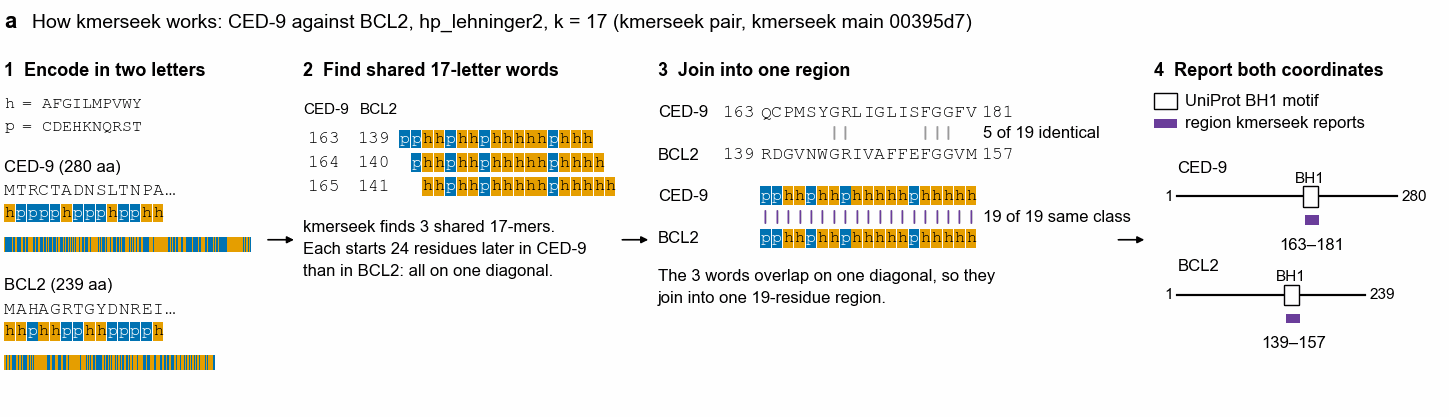

In [2]:
pair = json.loads(PAIR_JSON.read_text())
provenance = dict(
    line.split(": ", 1) for line in PAIR_PROVENANCE.read_text().splitlines()
)
print(PAIR_PROVENANCE.read_text())
check(
    provenance["kmerseek_commit"] == KMERSEEK_COMMIT,
    "the pair JSON was not made at the kmerseek commit named here",
)
check(
    pair["ksize"] == K_PAIR and pair["moltype"] == HP,
    f"pair JSON is {pair['moltype']} k={pair['ksize']}",
)
pair_classes = {c: res for c, res in pair["classes"].items()}
check(
    pair_classes == {"h": H_RES, "p": P_RES},
    f"kmerseek pair classes {pair_classes} differ from alphabets.rs",
)
to_pair_class = {r: c for c, res in pair_classes.items() for r in res}
pclass = lambda s: "".join(to_pair_class[r] for r in s)

ced9_seq, bcl2_seq = pair["query"]["sequence"], pair["target"]["sequence"]
check(
    "P41958" in pair["query"]["name"] and "P10415" in pair["target"]["name"],
    "query is not CED-9 or target is not BCL2",
)
words = pair["shared_kmers"]
for w in words:  # each word as kmerseek reports it is in both sequences at its position
    check(
        ced9_seq[w["query_pos"] : w["query_pos"] + K_PAIR] == w["query_kmer"],
        f"CED-9 word at {w['query_pos']}",
    )
    check(
        bcl2_seq[w["target_pos"] : w["target_pos"] + K_PAIR] == w["target_kmer"],
        f"BCL2 word at {w['target_pos']}",
    )
    check(
        pclass(w["query_kmer"]) == pclass(w["target_kmer"]) == w["kmer"],
        "a shared word is not the same in h/p",
    )
diagonals = {w["query_pos"] - w["target_pos"] for w in words}
check(
    len(pair["regions"]) == 1,
    f"kmerseek pair gives {len(pair['regions'])} regions, not 1",
)
check(
    len(words) == PAIR_EXPECTED["n_shared"],
    f"kmerseek pair gives {len(words)} shared {K_PAIR}-mers, not 3",
)
reg = pair["regions"][0]
ced9_r = (
    reg["query_start"] + 1,
    reg["query_end"],
)  # 0-based end-exclusive -> 1-based inclusive
bcl2_r = (reg["target_start"] + 1, reg["target_end"])
check(
    ced9_r == PAIR_EXPECTED["ced9"] and bcl2_r == PAIR_EXPECTED["bcl2"],
    f"region is CED-9 {ced9_r} / BCL2 {bcl2_r}, not 163-181 / 139-157",
)
check(len(diagonals) == 1, "the shared words are not on one diagonal")
check(
    min(w["query_pos"] for w in words) == reg["query_start"]
    and max(w["query_pos"] for w in words) + K_PAIR == reg["query_end"],
    "the region is not the union of the words",
)
region_len = reg["length"]
check(
    region_len == ced9_r[1] - ced9_r[0] + 1 == bcl2_r[1] - bcl2_r[0] + 1,
    "region length",
)
pair_offset = diagonals.pop()
ced9_reg, bcl2_reg = (
    ced9_seq[ced9_r[0] - 1 : ced9_r[1]],
    bcl2_seq[bcl2_r[0] - 1 : bcl2_r[1]],
)
ced9_reg_c, bcl2_reg_c = pclass(ced9_reg), pclass(bcl2_reg)
pair_identical = match_line(ced9_reg, bcl2_reg).count("|")
pair_same = match_line(ced9_reg_c, bcl2_reg_c).count("|")

motifs = {}
for acc, name in [("P41958", "CED-9"), ("P10415", "BCL2")]:
    entry = json.loads((PAIR_DIR / f"uniprot_{acc}.json").read_text())
    motifs[name] = {
        f["description"]: (
            f["location"]["start"]["value"],
            f["location"]["end"]["value"],
        )
        for f in entry["features"]
        if f["type"] == "Motif"
    }
overlap = lambda a, b: max(0, min(a[1], b[1]) - max(a[0], b[0]) + 1)
ced9_bh1, bcl2_bh1 = motifs["CED-9"]["BH1"], motifs["BCL2"]["BH1"]

print(
    f"kmerseek pair, {HP}, k = {K_PAIR}: {len(words)} shared {K_PAIR}-mers, {len(pair['regions'])} region"
)
for w in words:
    print(
        f"  CED-9 {w['query_pos'] + 1:>3}  BCL2 {w['target_pos'] + 1:>3}  {w['kmer']}  {w['query_kmer']} / {w['target_kmer']}"
    )
print(
    f"every word starts {pair_offset} residues later in CED-9 than in BCL2 (one diagonal)"
)
print(
    f"\nregion: CED-9 {ced9_r[0]}-{ced9_r[1]} with BCL2 {bcl2_r[0]}-{bcl2_r[1]}, {region_len} residues (1-based, inclusive)"
)
print(f"CED-9 {ced9_r[0]:>3} {ced9_reg} {ced9_r[1]}")
print(
    f"          {match_line(ced9_reg, bcl2_reg)} {pair_identical} of {region_len} identical"
)
print(f"BCL2  {bcl2_r[0]:>3} {bcl2_reg} {bcl2_r[1]}")
print(f"          {ced9_reg_c}")
print(
    f"          {match_line(ced9_reg_c, bcl2_reg_c)} {pair_same} of {region_len} same class"
)
print(f"          {bcl2_reg_c}")
print(
    f"\nUniProt BH1: CED-9 {ced9_bh1[0]}-{ced9_bh1[1]} ({overlap(ced9_bh1, ced9_r)} of {region_len} region residues inside), "
    f"BCL2 {bcl2_bh1[0]}-{bcl2_bh1[1]} ({overlap(bcl2_bh1, bcl2_r)} inside); BH1 offset {ced9_bh1[0] - bcl2_bh1[0]}"
)
print("all UniProt motifs:", motifs)

PITCH = 1.45  # mm per letter in panel a
STRIP = 0.112  # mm per residue in the whole-protein strips and lines of panel a
LEN = {"CED-9": len(ced9_seq), "BCL2": len(bcl2_seq)}


def draw_panel_a(cv, ox, oy):
    """Four steps, left to right, all from the kmerseek pair JSON."""
    cv.title(
        ox,
        oy + 47,
        "a",
        f"How kmerseek works: CED-9 against BCL2, {HP}, k = {K_PAIR} "
        f"(kmerseek pair, kmerseek main {KMERSEEK_COMMIT[:7]})",
    )
    head_y, xs = oy + 41.5, [ox, ox + 38, ox + 83, ox + 146]
    heads = [
        "1  Encode in two letters",
        f"2  Find shared {K_PAIR}-letter words",
        "3  Join into one region",
        "4  Report both coordinates",
    ]
    for x, s in zip(xs, heads):
        cv.text(x, head_y, s, fontsize=6.5, fontweight="bold")
    for x0, x1 in [
        (xs[1] - 4.5, xs[1] - 1.2),
        (xs[2] - 4.5, xs[2] - 1.2),
        (xs[3] - 4.5, xs[3] - 1.2),
    ]:
        cv.arrow(x0, x1, oy + 20)

    # 1. Encoding: the classes, the first residues of each protein, then each whole protein as a strip.
    x = xs[0]
    cv.text(x, oy + 37.2, "h", family=MONO, fontsize=6)
    cv.text(x + 2.2, oy + 37.2, f"= {pair_classes['h']}", family=MONO, fontsize=6)
    cv.text(x, oy + 34.4, "p", family=MONO, fontsize=6)
    cv.text(x + 2.2, oy + 34.4, f"= {pair_classes['p']}", family=MONO, fontsize=6)
    n_show = 14
    for (name, seq), y in zip(
        [("CED-9", ced9_seq), ("BCL2", bcl2_seq)], (oy + 27.6, oy + 12.6)
    ):
        cv.text(x, y + 1.6, f"{name} ({LEN[name]} aa)", fontsize=6)
        residues(cv, x, y - 1.4, seq[:n_show] + "…", PITCH)
        class_squares(cv, x, y - 4.2, pclass(seq[:n_show]), PITCH)
        sy = y - 8.2
        for i, c in enumerate(pclass(seq)):
            cv.rect(
                x + i * STRIP,
                sy - 1.0,
                STRIP * 1.15,
                2.0,
                facecolor=C_H if c == "h" else C_P,
                edgecolor="none",
                lw=0,
            )

    # 2. The shared words, one row each, shifted by their position, with their starts in both proteins.
    x = xs[1]
    cv.text(x, oy + 36.6, "CED-9", fontsize=5.5)
    cv.text(x + 7.2, oy + 36.6, "BCL2", fontsize=5.5)
    for n, w in enumerate(sorted(words, key=lambda w: w["query_pos"])):
        y = oy + 32.8 - n * 3.0
        cv.text(
            x + 4.6,
            y,
            str(w["query_pos"] + 1),
            family=MONO,
            fontsize=SEQ_PT,
            ha="right",
        )
        cv.text(
            x + 11.0,
            y,
            str(w["target_pos"] + 1),
            family=MONO,
            fontsize=SEQ_PT,
            ha="right",
        )
        class_squares(
            cv,
            x + 12.2 + (w["query_pos"] - reg["query_start"]) * PITCH,
            y,
            w["kmer"],
            PITCH,
        )
    cv.text(
        x, oy + 21.6, f"kmerseek finds {len(words)} shared {K_PAIR}-mers.", fontsize=6
    )
    cv.text(
        x, oy + 18.8, f"Each starts {pair_offset} residues later in CED-9", fontsize=6
    )
    cv.text(x, oy + 16.0, "than in BCL2: all on one diagonal.", fontsize=6)

    # 3. The region: residues with their match line, classes with theirs.
    x = xs[2]
    xseq = x + 13
    rows = {
        "q": oy + 36.2,
        "rm": oy + 33.5,
        "t": oy + 30.8,
        "qc": oy + 25.6,
        "cm": oy + 22.9,
        "tc": oy + 20.2,
    }
    for key, name, (s, e), seq in [
        ("q", "CED-9", ced9_r, ced9_reg),
        ("t", "BCL2", bcl2_r, bcl2_reg),
    ]:
        cv.text(x, rows[key], name, fontsize=6)
        cv.text(xseq - 0.7, rows[key], str(s), family=MONO, fontsize=SEQ_PT, ha="right")
        cv.text(
            xseq + region_len * PITCH + 0.5,
            rows[key],
            str(e),
            family=MONO,
            fontsize=SEQ_PT,
        )
        residues(cv, xseq, rows[key], seq, PITCH)
    for key, name, cl in [("qc", "CED-9", ced9_reg_c), ("tc", "BCL2", bcl2_reg_c)]:
        cv.text(x, rows[key], name, fontsize=6)
        class_squares(cv, xseq, rows[key], cl, PITCH)
    residues(
        cv,
        xseq,
        rows["rm"],
        match_line(ced9_reg, bcl2_reg),
        PITCH,
        color=C_AA,
        fontweight="bold",
    )
    residues(
        cv,
        xseq,
        rows["cm"],
        match_line(ced9_reg_c, bcl2_reg_c),
        PITCH,
        color=C_HP,
        fontweight="bold",
    )
    cv.text(
        xseq + region_len * PITCH + 0.8,
        rows["rm"],
        f"{pair_identical} of {region_len} identical",
        fontsize=6,
    )
    cv.text(
        xseq + region_len * PITCH + 0.8,
        rows["cm"],
        f"{pair_same} of {region_len} same class",
        fontsize=6,
    )
    cv.text(
        x,
        oy + 15.4,
        f"The {len(words)} words overlap on one diagonal, so they",
        fontsize=6,
    )
    cv.text(x, oy + 12.6, f"join into one {region_len}-residue region.", fontsize=6)

    # 4. Coordinates: each protein as a line, UniProt BH1 as a box, the region as a purple bar under it.
    x = xs[3] + 3
    for name, y, (s, e), bh1 in [
        ("CED-9", oy + 25.5, ced9_r, ced9_bh1),
        ("BCL2", oy + 13.0, bcl2_r, bcl2_bh1),
    ]:
        L = LEN[name]
        sx = lambda r: x + (r - 1) * 0.1
        cv.text(x, y + 3.6, f"{name}", fontsize=6)
        cv.line([sx(1), sx(L)], [y, y], color="black", lw=0.8)
        cv.rect(
            sx(bh1[0]),
            y - 1.3,
            sx(bh1[1]) - sx(bh1[0]),
            2.6,
            facecolor="white",
            edgecolor="black",
            lw=0.5,
            zorder=3,
        )
        cv.text(
            (sx(bh1[0]) + sx(bh1[1])) / 2, y + 2.3, "BH1", fontsize=5.5, ha="center"
        )
        cv.rect(sx(s), y - 3.6, sx(e) - sx(s), 1.2, facecolor=C_HP, edgecolor="none")
        cv.text(
            (sx(s) + sx(e)) / 2, y - 5.2, f"{s}–{e}", fontsize=6, ha="center", va="top"
        )
        cv.text(sx(1) - 0.6, y, "1", fontsize=5.5, ha="right")
        cv.text(sx(L) + 0.6, y, str(L), fontsize=5.5)
    ky = oy + 37.6
    x = xs[3]
    cv.rect(x, ky - 1.0, 3.0, 2.0, facecolor="white", edgecolor="black", lw=0.5)
    cv.text(x + 4.0, ky, "UniProt BH1 motif", fontsize=6)
    cv.rect(x, ky - 3.4, 3.0, 1.2, facecolor=C_HP, edgecolor="none")
    cv.text(x + 4.0, ky - 2.8, "region kmerseek reports", fontsize=6)


draw_panel_a(Canvas(pf.TWO_COLUMN_MM, 52), 0, 2)

## 2. All pairs: kappa by identity bin (Figure 1b)

Kappa is recomputed for every identity bin from notebook 230's per-pair values: the mean over
pairs, with a 95% bootstrap interval over pairs (`hc.bootstrap_mean_ci`, 500 resamples, seed 0).
The intervals are shorter than the dots, so they are reported in the caption and the table, not
drawn. The 20-30% bin is checked against the PR 53 table, which used the same code. Each bin
includes its upper edge (`pl.cut` is right-closed): a pair at exactly 20% identity is in the
first bin.

shape: (10, 7)
┌───────────────┬──────────────┬─────────┬────────┬──────────┬──────────┬────────────┐
│ alphabet      ┆ identity_bin ┆ n_pairs ┆ kappa  ┆ kappa_lo ┆ kappa_hi ┆ hp_over_aa │
│ ---           ┆ ---          ┆ ---     ┆ ---    ┆ ---      ┆ ---      ┆ ---        │
│ str           ┆ str          ┆ i64     ┆ f64    ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════╪══════════════╪═════════╪════════╪══════════╪══════════╪════════════╡
│ hp_lehninger2 ┆ <20%         ┆ 16407   ┆ 0.294  ┆ 0.2925   ┆ 0.2957   ┆ 2.76       │
│ hp_lehninger2 ┆ 20-30%       ┆ 37085   ┆ 0.3944 ┆ 0.3934   ┆ 0.3954   ┆ 1.98       │
│ hp_lehninger2 ┆ 30-40%       ┆ 34512   ┆ 0.4894 ┆ 0.4884   ┆ 0.4904   ┆ 1.63       │
│ hp_lehninger2 ┆ 40-60%       ┆ 41508   ┆ 0.616  ┆ 0.6151   ┆ 0.6168   ┆ 1.37       │
│ hp_lehninger2 ┆ >=60%        ┆ 18970   ┆ 0.7797 ┆ 0.7785   ┆ 0.7809   ┆ 1.16       │
│ protein20     ┆ <20%         ┆ 16407   ┆ 0.1065 ┆ 0.1061   ┆ 0.107    ┆ 2.76       │
│ protein20     ┆ 20-30%    

<Axes: xlabel='identity of the pair (top), number of pairs (below)', ylabel="Cohen's kappa (0 = chance)">

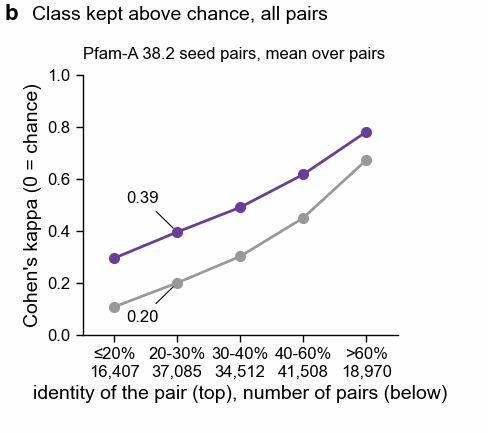

In [3]:
pairs_all = hc.add_identity_bin(pl.read_parquet(PAIR_TABLE)).filter(
    pl.col("n_cols") >= MIN_COLS
)
rows_b = []
for a in (HP, AA, HP_SUPP):
    for b in hc.IDENTITY_LABELS:
        x = pairs_all.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b))[
            "kappa"
        ].to_numpy()
        m, lo, hi = hc.bootstrap_mean_ci(x)
        rows_b.append(
            {
                "alphabet": a,
                "identity_bin": b,
                "n_pairs": x.size,
                "kappa": m,
                "kappa_lo": lo,
                "kappa_hi": hi,
            }
        )
kappa_bins = pl.DataFrame(rows_b)
BIN_SHOWN = {
    "<20%": "≤20%",
    "20-30%": "20-30%",
    "30-40%": "30-40%",
    "40-60%": "40-60%",
    ">=60%": ">60%",
}
check(
    list(BIN_SHOWN) == hc.IDENTITY_LABELS,
    "identity bin labels changed in hp_conservation_utils",
)
kc = {(r["alphabet"], r["identity_bin"]): r for r in kappa_bins.iter_rows(named=True)}
ratio_by_bin = {
    b: kc[(HP, b)]["kappa"] / kc[(AA, b)]["kappa"] for b in hc.IDENTITY_LABELS
}
print(
    kappa_bins.filter(pl.col("alphabet") != HP_SUPP).with_columns(
        pl.col("kappa", "kappa_lo", "kappa_hi").round(4),
        pl.col("identity_bin")
        .cast(pl.String)
        .replace_strict(ratio_by_bin, return_dtype=pl.Float64)
        .round(2)
        .alias("hp_over_aa"),
    )
)

check(
    hashlib.sha256(KAPPA_TSV.read_bytes()).hexdigest() == KAPPA_TSV_SHA256,
    f"{KAPPA_TSV.name} changed",
)
tsv = pl.read_csv(KAPPA_TSV, separator="\t", comment_prefix="#")
for a in (HP, AA, HP_SUPP):
    mine, ref = kc[(a, BIN)], tsv.filter(pl.col("alphabet") == a).row(0, named=True)
    for col in ("kappa", "kappa_lo", "kappa_hi"):
        check(
            round(mine[col], 4) == ref[col],
            f"{a} {col}: {mine[col]:.4f} here, {ref[col]} in the PR 53 table",
        )
    check(
        mine["n_pairs"] == ref["n_pairs"],
        f"{a}: {mine['n_pairs']} pairs here, {ref['n_pairs']} in the table",
    )
print(
    f"\n{BIN} bin matches the PR 53 table to 4 decimals for {HP}, {AA} and {HP_SUPP}."
)
n_pairs = kc[(HP, BIN)]["n_pairs"]
check(
    n_pairs == kc[(HP_SUPP, BIN)]["n_pairs"],
    "the two H/P alphabets have different pair counts",
)


def draw_panel_b(cv, ox, oy, w=40, h=33):
    """Kappa by identity bin, H/P (purple) and 20 amino acids (grey)."""
    cv.title(ox, oy + h + 17, "b", "Class kept above chance, all pairs")
    ax = cv.axes(ox + 10, oy + 10, w, h)
    xs = np.arange(len(hc.IDENTITY_LABELS))
    for a, color in [(HP, C_HP), (AA, C_AA)]:
        ax.plot(
            xs,
            [kc[(a, b)]["kappa"] for b in hc.IDENTITY_LABELS],
            color=color,
            marker="o",
        )
    i = hc.IDENTITY_LABELS.index(BIN)
    for a, dy in [(HP, 0.13), (AA, -0.13)]:
        v = kc[(a, BIN)]["kappa"]
        ax.annotate(
            f"{v:.2f}",
            (i, v),
            (i - 0.55, v + dy),
            fontsize=6,
            ha="center",
            va="center",
            arrowprops=dict(
                arrowstyle="-", lw=0.4, color="black", shrinkA=0, shrinkB=2
            ),
        )
    ax.set_xticks(
        xs, [f"{BIN_SHOWN[b]}\n{kc[(HP, b)]['n_pairs']:,}" for b in hc.IDENTITY_LABELS]
    )
    ax.set_xlim(-0.5, len(xs) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel("identity of the pair (top), number of pairs (below)")
    ax.set_ylabel("Cohen's kappa (0 = chance)")
    cv.text(
        ox + 10, oy + h + 12.6, "Pfam-A 38.2 seed pairs, mean over pairs", fontsize=6
    )
    return ax


draw_panel_b(Canvas(61, 54), 0, 2)

## 3. Swiss-Prot: residue counts and sequences

One pass over Swiss-Prot 2026_03: the letter counts give each H/P alphabet's bits per letter and
k\* (the Figure 3 draft), and the full sequences of the supplementary dot-plot candidates.

In [4]:
aln = pl.read_parquet(ALIGNMENTS).select("family", "query", "target", "qaln", "taln")
cand_pairs = (
    pairs_all.filter(
        (pl.col("alphabet") == HP_SUPP)
        & (pl.col("identity_bin") == BIN)
        & (pl.col("longest_run") >= K_SUPP)
    )
    .filter(
        pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
        & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean)
    )
    .join(aln, on=["family", "query", "target"], how="inner")
)
want = {
    n.split("/")[0]
    for n in cand_pairs["query"].to_list() + cand_pairs["target"].to_list()
}

sprot_counts = np.zeros(256, dtype=np.int64)
sprot_seqs, n_sprot_seq, name, buf = {}, 0, None, []
with gzip.open(SWISSPROT, "rt") as fh:
    for line in fh:
        if line.startswith(">"):
            if name in want:
                sprot_seqs[name] = "".join(buf)
            n_sprot_seq += 1
            name, buf = line.split("|")[2].split()[0], []
        else:
            s = line.strip()
            sprot_counts += np.bincount(
                np.frombuffer(s.encode(), dtype=np.uint8), minlength=256
            )
            if name in want:
                buf.append(s)
    if name in want:
        sprot_seqs[name] = "".join(buf)
aa_counts = np.array([sprot_counts[ord(r)] for r in STANDARD], dtype=float)
b_aa = -math.log2(((aa_counts / aa_counts.sum()) ** 2).sum())


def hp_bits(alphabet: str) -> dict:
    """Swiss-Prot class shares, bits per H/P letter (B_alpha) and k* for one H/P alphabet."""
    h_res, p_res = hp_classes[alphabet]
    n_h, n_p = (int(sum(sprot_counts[ord(r)] for r in cl)) for cl in (h_res, p_res))
    n = n_h + n_p
    h, p = n_h / n, n_p / n
    pr_same = h * h + p * p  # h_query h_target + p_query p_target, Swiss-Prot shares
    b = -math.log2(pr_same)
    return {
        "n_res": n,
        "n_other": int(sprot_counts.sum()) - n,
        "h": h,
        "p": p,
        "pr_same": pr_same,
        "b_alpha": b,
        "kstar_exact": math.log2(n) / b,
        "kstar": math.ceil(math.log2(n) / b),
    }


bits = {a: hp_bits(a) for a in (HP, HP_SUPP)}
print(
    f"Swiss-Prot 2026_03: {n_sprot_seq:,} sequences; B_aa = {b_aa:.3f} bits per amino acid"
)
for a, d in bits.items():
    print(
        f"{a}: h = {d['h']:.4f}, p = {d['p']:.4f}, B_alpha = {d['b_alpha']:.4f} bits, k* = ceil({d['kstar_exact']:.2f}) = {d['kstar']}"
    )

Swiss-Prot 2026_03: 575,748 sequences; B_aa = 4.064 bits per amino acid
hp_lehninger2: h = 0.5280, p = 0.4720, B_alpha = 0.9955 bits, k* = ceil(27.76) = 28
hp_thomas_dill2: h = 0.4236, p = 0.5764, B_alpha = 0.9667 bits, k* = ceil(28.59) = 29


## 4. Run lengths: real pairs, independent positions, shuffled (Figure 1c and the Figure 3 draft)

Three curves for the 20-30% bin, `hp_lehninger2`:

1. **Real pairs**: notebook 230's longest same-class run per pair, recomputed from the alignments
   here and checked against the saved value.
2. **Independent-position prediction**: for each pair, `Pr(agree)` is its share of aligned
   positions in the same class (notebook 230's `agree`). The chance of a run of at least k, if
   every aligned position kept its class on its own with that probability, is computed exactly
   (`hc.pr_longest_run_at_least`) and averaged over pairs. A run stops at an alignment gap, as it
   does for the real pairs. A version that joins each pair's aligned positions into one unbroken
   stretch is printed but not drawn.
3. **Shuffled**: the target's residues shuffled among its own residue positions (composition and
   gaps kept), 20 times per pair with a fixed seed.

Figure 1c draws the three curves. The Figure 3 draft adds real divided by predicted (1 means real
runs are as long as independent positions give, above 1 that same-class positions cluster) and k\*.

shape: (15, 6)
┌───────┬───────────┬─────┬───────────┬────────┬───────────────┐
│ pair  ┆ Pr(agree) ┆ k   ┆ simulated ┆ exact  ┆ within 4 s.e. │
│ ---   ┆ ---       ┆ --- ┆ ---       ┆ ---    ┆ ---           │
│ i64   ┆ f64       ┆ i64 ┆ f64       ┆ f64    ┆ bool          │
╞═══════╪═══════════╪═════╪═══════════╪════════╪═══════════════╡
│ 0     ┆ 0.692     ┆ 8   ┆ 0.9808    ┆ 0.9795 ┆ true          │
│ 0     ┆ 0.692     ┆ 12  ┆ 0.4906    ┆ 0.4917 ┆ true          │
│ 0     ┆ 0.692     ┆ 16  ┆ 0.1102    ┆ 0.1183 ┆ true          │
│ 9271  ┆ 0.679     ┆ 8   ┆ 0.9684    ┆ 0.9637 ┆ true          │
│ 9271  ┆ 0.679     ┆ 12  ┆ 0.4406    ┆ 0.433  ┆ true          │
│ 9271  ┆ 0.679     ┆ 16  ┆ 0.098     ┆ 0.0974 ┆ true          │
│ 18542 ┆ 0.758     ┆ 8   ┆ 0.9486    ┆ 0.9505 ┆ true          │
│ 18542 ┆ 0.758     ┆ 12  ┆ 0.461     ┆ 0.4636 ┆ true          │
│ 18542 ┆ 0.758     ┆ 16  ┆ 0.1146    ┆ 0.1202 ┆ true          │
│ 27813 ┆ 0.795     ┆ 8   ┆ 0.99      ┆ 0.9899 ┆ true          │
│ 27813 ┆ 

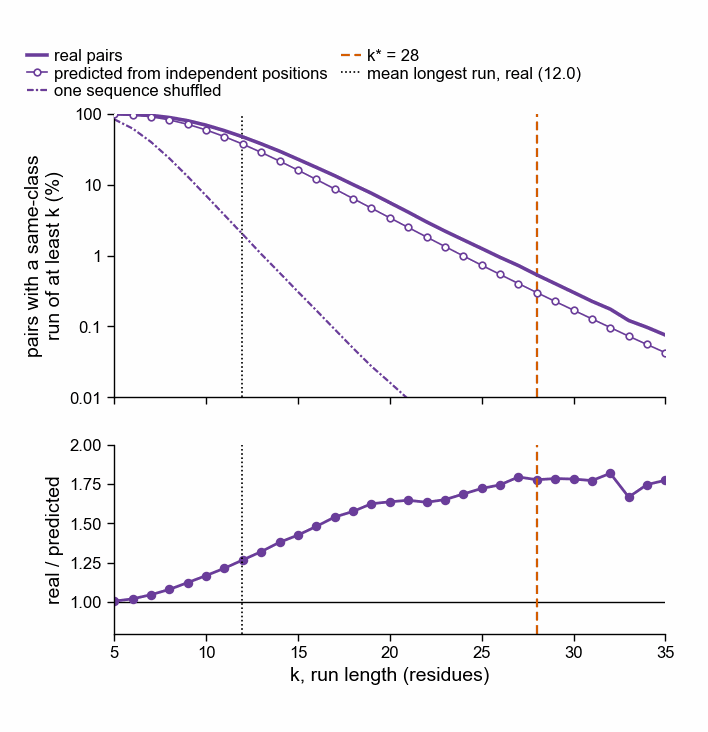

In [5]:
hp = pairs_all.filter((pl.col("alphabet") == HP) & (pl.col("identity_bin") == BIN))
hp_aln = hp.join(aln, on=["family", "query", "target"], how="inner").sort(
    "family", "query", "target"
)
check(
    hp_aln.height == n_pairs == hp.height,
    "an alignment is missing for a pair in the bin",
)
tab = hc.TABLES[HP]
rng = np.random.default_rng(0)
real_runs = np.empty(n_pairs, dtype=np.int64)
null_runs = np.empty((N_SHUFFLE, n_pairs), dtype=np.int64)
stretches = []
for i, (qa_s, ta_s) in enumerate(hp_aln.select("qaln", "taln").iter_rows()):
    qcl = tab[np.frombuffer(qa_s.encode(), dtype=np.uint8)]
    tcl = tab[np.frombuffer(ta_s.encode(), dtype=np.uint8)]
    both = (qcl != hc.GAP) & (tcl != hc.GAP)
    real_runs[i] = hc.longest_true_run((qcl == tcl) & both)
    res_idx = np.flatnonzero(tcl != hc.GAP)
    for r in range(N_SHUFFLE):
        shuffled = tcl.copy()
        shuffled[res_idx] = tcl[rng.permutation(res_idx)]
        null_runs[r, i] = hc.longest_true_run((qcl == shuffled) & both)
    stretches.append(hc.aligned_stretches(qa_s, ta_s))
check(
    np.array_equal(real_runs, hp_aln["longest_run"].to_numpy()),
    "recomputed runs differ from 230's",
)
pr_agree = hp_aln["agree"].to_numpy()
n_aligned = hp_aln["n_cols"].to_numpy()
check(
    np.array_equal(np.array([s.sum() for s in stretches]), n_aligned),
    "stretch lengths do not add up to n_cols",
)

ks = np.array(KS)
pred_pair = hc.pr_longest_run_at_least(pr_agree, stretches, ks)
pred_one_pair = hc.pr_longest_run_at_least(
    pr_agree, [np.array([n]) for n in n_aligned], ks
)
share_real = (real_runs[None, :] >= ks[:, None]).mean(axis=1)
share_pred = pred_pair.mean(axis=1)
share_pred_one = pred_one_pair.mean(axis=1)
share_null = (null_runs[:, None, :] >= ks[None, :, None]).mean(axis=2).mean(axis=0)
mean_run, mean_run_null = float(real_runs.mean()), float(null_runs.mean())
median_run = float(np.median(real_runs))
mean_pr_agree = float(pr_agree.mean())

sim_rng = np.random.default_rng(1)
sim_rows = []
for i in np.linspace(0, n_pairs - 1, 5).astype(int):
    best = np.zeros(N_SIM, dtype=np.int64)
    for L in stretches[i]:
        draws = sim_rng.random((N_SIM, L)) < pr_agree[i]
        dd = np.diff(np.pad(draws, ((0, 0), (1, 1))).astype(np.int8), axis=1)
        for s in range(N_SIM):
            st, en = np.flatnonzero(dd[s] == 1), np.flatnonzero(dd[s] == -1)
            if st.size:
                best[s] = max(best[s], (en - st).max())
    for k in (8, 12, 16):
        sim, exact = (best >= k).mean(), pred_pair[k - KS[0], i]
        sim_rows.append(
            {
                "pair": i,
                "Pr(agree)": round(pr_agree[i], 3),
                "k": k,
                "simulated": sim,
                "exact": exact,
                "within 4 s.e.": bool(
                    abs(sim - exact)
                    <= 4 * math.sqrt(max(exact * (1 - exact), 1e-12) / N_SIM)
                ),
            }
        )
sim_check = pl.DataFrame(sim_rows)
print(sim_check.with_columns(pl.col("simulated", "exact").round(4)))
check(sim_check["within 4 s.e."].all(), "exact prediction disagrees with simulation")

kstar = bits[HP]["kstar"]
at = lambda arr, k: float(arr[k - KS[0]])
tail = pl.DataFrame(
    {
        "k": KS_TABLE,
        "real_pct": [100 * at(share_real, k) for k in KS_TABLE],
        "predicted_pct": [100 * at(share_pred, k) for k in KS_TABLE],
        "real_over_predicted": [
            at(share_real, k) / at(share_pred, k) for k in KS_TABLE
        ],
        "predicted_one_stretch_pct": [100 * at(share_pred_one, k) for k in KS_TABLE],
        "real_over_one_stretch": [
            at(share_real, k) / at(share_pred_one, k) for k in KS_TABLE
        ],
        "shuffled_pct": [100 * at(share_null, k) for k in KS_TABLE],
    }
)
print(
    f"\n{HP}, {n_pairs:,} pairs at {BIN}: mean Pr(agree) {mean_pr_agree:.3f}; mean longest same-class run: real "
    f"{mean_run:.2f} (median {median_run:.0f}), shuffled {mean_run_null:.2f}"
)
print(tail.with_columns(pl.exclude("k").round(3)))
K_RATIO_FROM = 17
tail_ks = range(K_RATIO_FROM, KS[-1] + 1)
ratio_lo, ratio_hi = (
    f(at(share_real, k) / at(share_pred, k) for k in tail_ks) for f in (min, max)
)
one_lo, one_hi = (
    f(at(share_real, k) / at(share_pred_one, k) for k in tail_ks) for f in (min, max)
)
first_above = min(k for k in KS if at(share_real, k) > at(share_pred, k))
print(
    f"real pairs above the prediction from k = {first_above}; at k = {K_RATIO_FROM}-{KS[-1]}, real / predicted = "
    f"{ratio_lo:.2f}-{ratio_hi:.2f}; against the one-stretch version {one_lo:.2f}-{one_hi:.2f}"
)

K_TICKS = [5, 10, 15, 20, 25, 30, 35]


def draw_fig3_draft(cv, ox, oy):
    """Top: share of pairs with a run of at least k. Bottom: real divided by predicted."""
    ax = cv.axes(ox + 12, oy + 42, 70, 36)
    ax.plot(KS, 100 * share_real, color=C_HP, lw=1.3, zorder=3, label="real pairs")
    ax.plot(
        KS,
        100 * share_pred,
        color=C_HP,
        lw=0.6,
        marker="o",
        ms=2.4,
        mfc="white",
        mew=0.6,
        zorder=4,
        label="predicted from independent positions",
    )
    ax.plot(
        KS,
        100 * share_null,
        color=C_HP,
        lw=0.8,
        ls=(0, (3, 1, 1, 1)),
        zorder=2,
        label="one sequence shuffled",
    )
    ax.axvline(
        kstar, color=C_KSTAR, lw=0.8, ls=(0, (4, 2)), zorder=0, label=f"k* = {kstar}"
    )
    ax.axvline(
        mean_run,
        color="black",
        lw=0.6,
        ls=(0, (1, 1.5)),
        zorder=0,
        label=f"mean longest run, real ({mean_run:.1f})",
    )
    ax.set_yscale("log")
    ax.set_ylim(0.01, 100)
    ax.set_yticks([0.01, 0.1, 1, 10, 100], ["0.01", "0.1", "1", "10", "100"])
    ax.minorticks_off()
    ax.set_xlim(KS[0], KS[-1])
    ax.set_xticks(K_TICKS)
    ax.tick_params(labelbottom=False)
    ax.set_ylabel("pairs with a same-class\nrun of at least k (%)")
    ax.legend(
        loc="lower left",
        bbox_to_anchor=(-0.17, 1.03),
        ncol=2,
        borderaxespad=0,
        labelspacing=0.15,
        columnspacing=0.8,
    )
    axr = cv.axes(ox + 12, oy + 12, 70, 24)
    axr.axhline(1, color="black", lw=0.5)
    axr.plot(KS, share_real / share_pred, color=C_HP, lw=1.0, marker="o", ms=2.4)
    axr.axvline(kstar, color=C_KSTAR, lw=0.8, ls=(0, (4, 2)))
    axr.axvline(mean_run, color="black", lw=0.6, ls=(0, (1, 1.5)))
    axr.set_xlim(KS[0], KS[-1])
    axr.set_xticks(K_TICKS)
    ratios = share_real / share_pred
    axr.set_ylim(0.8, max(1.6, math.ceil(ratios.max() * 5) / 5))
    axr.set_xlabel("k, run length (residues)")
    axr.set_ylabel("real / predicted")
    return ax, axr


cv = Canvas(89, 92)
draw_fig3_draft(cv, 2, 0)
FIG3 = "fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct"
cv.fig.savefig(FIG / f"{FIG3}.pdf")
save_png(cv.fig, FIG / f"{FIG3}.png")

## 5. The seed-length trade (Figure 1d)

PR 113's tables, exact seeds only (no mismatches, no spaced or chained seeds), `hp_lehninger2`:

* **Top**: share of the Pfam seed pairs at 20-30% identity whose own alignment diagonal holds at
  least one shared k-mer. PR 113 keeps pairs with `lali` >= 50 (aligned positions with no gap in
  either sequence), notebook 230 with `n_cols` >= 50 (the same, but only positions where both
  residues are one of the 20 standard amino acids). PR 113 has one pair more in this bin:
  PF21551, A0A1E5S0R7_HANUV/19-76 against A0A9P8PQV4_9ASCO/10-59 (`lali` 50, `n_cols` 49).
* **Bottom**: human proteins (UniProt reference proteome, one protein per gene) that share at least
  one k-mer with CED-9, out of 19,732.
* **Band**: the k-mer sizes kmerseek tests for `hp_lehninger2`, `k_min` to `k_max` from PR 101's
  table (human Swiss-Prot).

shape: (10, 4)
┌─────┬──────────────────────┬───────────────────────────┬──────────────────────────┐
│ k   ┆ pfam_pairs_with_seed ┆ pfam_run_at_least_k_nb230 ┆ human_proteins_with_seed │
│ --- ┆ ---                  ┆ ---                       ┆ ---                      │
│ i64 ┆ f64                  ┆ f64                       ┆ i64                      │
╞═════╪══════════════════════╪═══════════════════════════╪══════════════════════════╡
│ 8   ┆ 0.8872               ┆ 0.8873                    ┆ 19731                    │
│ 10  ┆ 0.6917               ┆ 0.6918                    ┆ 19723                    │
│ 12  ┆ 0.4727               ┆ 0.4728                    ┆ 19647                    │
│ 14  ┆ 0.2971               ┆ 0.2971                    ┆ 18326                    │
│ 16  ┆ 0.1753               ┆ 0.1754                    ┆ 12691                    │
│ 18  ┆ 0.1004               ┆ 0.1004                    ┆ 5597                     │
│ 20  ┆ 0.0558               ┆ 0.0558  

(<Axes: ylabel='Pfam pairs\nwith a seed (%)'>,
 <Axes: xlabel='k, seed length (residues)', ylabel='human proteins\nwith a seed'>)

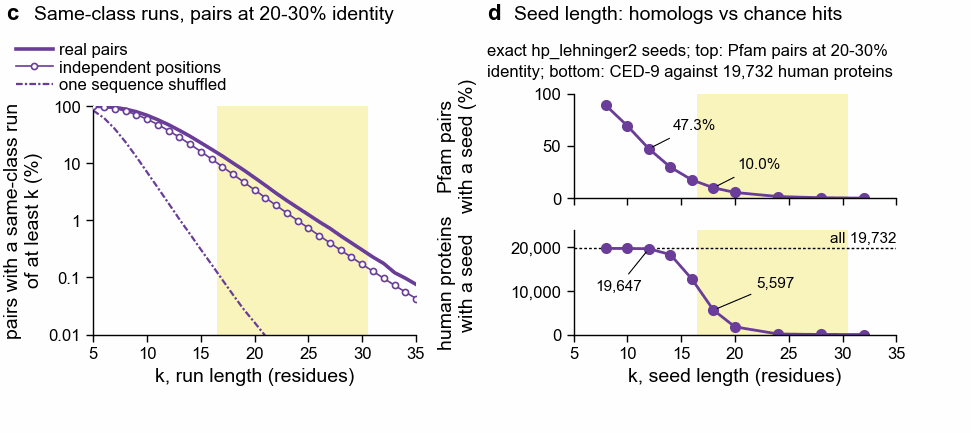

In [6]:
reach = pl.read_csv(
    io.StringIO(git_show(REPO, SEEDS_COMMIT, "tables/246_pfam_seed_pairs_reach.tsv")),
    separator="\t",
)
human = pl.read_csv(
    io.StringIO(git_show(REPO, SEEDS_COMMIT, "tables/246_human_proteome_search.tsv")),
    separator="\t",
)
ksizes = pl.read_csv(
    io.StringIO(
        git_show(
            REPO,
            KSIZES_COMMIT,
            "tables/274_ksizes_to_test_per_alphabet_human_swissprot.csv",
        )
    )
)
exact = pl.col("scheme").str.contains(r"^exact k=\d+$")
kcol = pl.col("scheme").str.extract(r"(\d+)$").cast(pl.Int64).alias("k")
reach_hp = (
    reach.filter(exact & (pl.col("alphabet") == HP) & (pl.col("identity_bin") == BIN))
    .with_columns(kcol)
    .sort("k")
)
human_hp = (
    human.filter(exact & (pl.col("alphabet") == HP) & (pl.col("query") == "CED-9"))
    .with_columns(kcol)
    .sort("k")
)
check(
    human_hp["n_proteins"].unique().to_list() == [N_HUMAN],
    f"human proteome is not {N_HUMAN:,} proteins",
)
check(
    reach_hp["k"].to_list() == human_hp["k"].to_list(),
    "the two PR 113 tables have different k",
)
seed_k = reach_hp["k"].to_list()
seed_share = dict(zip(seed_k, reach_hp["fraction_of_pairs_with_seed"].to_list()))
seed_human = dict(zip(seed_k, human_hp["n_proteins_with_seed"].to_list()))
n_pairs_seed = int(reach_hp["n_pairs"].unique().item())
for k, (share, n_hum) in SEED_EXPECTED.items():
    check(
        round(seed_share[k], 3) == share,
        f"k={k}: Pfam share {seed_share[k]:.4f}, expected {share}",
    )
    check(
        seed_human[k] == n_hum,
        f"k={k}: {seed_human[k]:,} human proteins, expected {n_hum:,}",
    )
krow = ksizes.filter(pl.col("alphabet") == HP).row(0, named=True)
check(
    krow["letter_classes"] == f"{H_RES} {P_RES}",
    f"PR 101's {HP} classes differ: {krow['letter_classes']}",
)
k_min, k_max = int(krow["k_min"]), int(krow["k_max"])
print(
    pl.DataFrame(
        {
            "k": seed_k,
            "pfam_pairs_with_seed": [seed_share[k] for k in seed_k],
            "pfam_run_at_least_k_nb230": [at(share_real, k) for k in seed_k],
            "human_proteins_with_seed": [seed_human[k] for k in seed_k],
        }
    ).with_columns(pl.col("^pfam.*$").round(4))
)
print(
    f"PR 113 Pfam pairs at {BIN}: {n_pairs_seed:,} (notebook 230 filter: {n_pairs:,}); k range kmerseek tests for {HP}: "
    f"{k_min}-{k_max} (PR 101)"
)
print(
    f"asserted: k=12 -> {seed_share[12]:.3f} and {seed_human[12]:,}; k=18 -> {seed_share[18]:.3f} and {seed_human[18]:,}"
)


def k_band(ax):
    ax.axvspan(k_min - 0.5, k_max + 0.5, color=C_KRANGE, alpha=0.35, lw=0, zorder=0)


def draw_panel_c(cv, ox, oy, w=41, h=33, h_ax=29):
    """Share of 20-30% pairs whose longest same-class run is at least k: real, independent positions, shuffled."""
    cv.title(ox, oy + h + 17, "c", f"Same-class runs, pairs at {BIN} identity")
    ax = cv.axes(ox + 11, oy + 10, w, h_ax)
    k_band(ax)
    ax.plot(KS, 100 * share_real, color=C_HP, lw=1.3, zorder=3, label="real pairs")
    ax.plot(
        KS,
        100 * share_pred,
        color=C_HP,
        lw=0.6,
        marker="o",
        ms=2.2,
        mfc="white",
        mew=0.6,
        zorder=4,
        label="independent positions",
    )
    ax.plot(
        KS,
        100 * share_null,
        color=C_HP,
        lw=0.8,
        ls=(0, (3, 1, 1, 1)),
        zorder=2,
        label="one sequence shuffled",
    )
    ax.set_yscale("log")
    ax.set_ylim(0.01, 100)
    ax.set_yticks([0.01, 0.1, 1, 10, 100], ["0.01", "0.1", "1", "10", "100"])
    ax.minorticks_off()
    ax.set_xlim(KS[0], KS[-1])
    ax.set_xticks(K_TICKS)
    ax.set_xlabel("k, run length (residues)")
    ax.set_ylabel("pairs with a same-class run\nof at least k (%)")
    ax.legend(
        loc="lower left",
        bbox_to_anchor=(-0.26, 1.03),
        ncol=1,
        borderaxespad=0,
        labelspacing=0.15,
        handlelength=2.2,
    )
    return ax


def draw_panel_d(cv, ox, oy, w=41, h=13.3, gap=4):
    """Top: Pfam pairs at 20-30% sharing a seed. Bottom: human proteins sharing a seed with CED-9."""
    cv.title(ox, oy + 50, "d", "Seed length: homologs vs chance hits")
    cv.text(ox, oy + 46.0, f"exact {HP} seeds; top: Pfam pairs at {BIN}", fontsize=6)
    cv.text(
        ox,
        oy + 43.4,
        f"identity; bottom: CED-9 against {N_HUMAN:,} human proteins",
        fontsize=6,
    )
    axb = cv.axes(ox + 11, oy + 10, w, h)
    axt = cv.axes(ox + 11, oy + 10 + h + gap, w, h)
    ks_d = np.array(seed_k)
    for ax in (axt, axb):
        k_band(ax)
        ax.set_xlim(KS[0], KS[-1])
        ax.set_xticks(K_TICKS)
    axt.plot(ks_d, [100 * seed_share[k] for k in seed_k], color=C_HP, marker="o")
    axt.set_ylim(0, 100)
    axt.set_yticks([0, 50, 100])
    axt.tick_params(labelbottom=False)
    axt.set_ylabel("Pfam pairs\nwith a seed (%)")
    axb.axhline(N_HUMAN, color="black", lw=0.5, ls=(0, (2, 1.5)), zorder=1)
    axb.text(
        KS[-1],
        N_HUMAN * 1.04,
        f"all {N_HUMAN:,}",
        fontsize=5.5,
        ha="right",
        va="bottom",
    )
    axb.plot(ks_d, [seed_human[k] for k in seed_k], color=C_HP, marker="o")
    axb.set_ylim(0, 24_000)
    axb.set_yticks([0, 10_000, 20_000], ["0", "10,000", "20,000"])
    axb.set_ylabel("human proteins\nwith a seed")
    for ax in (axt, axb):
        ax.yaxis.set_label_coords(-0.3, 0.5)
    axb.set_xlabel("k, seed length (residues)")
    for k in SEED_EXPECTED:
        axt.annotate(
            f"{100 * seed_share[k]:.1f}%",
            (k, 100 * seed_share[k]),
            (k + 2.2, 100 * seed_share[k] + 22),
            fontsize=5.5,
            ha="left",
            va="center",
            arrowprops=dict(
                arrowstyle="-", lw=0.4, color="black", shrinkA=0, shrinkB=1.5
            ),
        )
        xy_text = (7, 11_000) if k < 15 else (k + 4, seed_human[k] + 6_000)
        axb.annotate(
            f"{seed_human[k]:,}",
            (k, seed_human[k]),
            xy_text,
            fontsize=5.5,
            ha="left",
            va="center",
            arrowprops=dict(
                arrowstyle="-", lw=0.4, color="black", shrinkA=0, shrinkB=1.5
            ),
        )
    return axt, axb


cv = Canvas(122, 54)
draw_panel_c(cv, 0, 2)
draw_panel_d(cv, 61, 2)

## 6. Supplementary figure: the previous Figure 1's panels a and c, in `hp_thomas_dill2`

Kept as they were, moved out of Figure 1 when it changed to `hp_lehninger2`.

**One typical pair.** Among the 20-30% pairs whose longest `hp_thomas_dill2` same-class run
equals the bin's median, keep those with no gap, at most 80 aligned positions, and both sequences
reviewed Swiss-Prot entries; take the pair whose own kappa is closest to the bin's mean kappa.

**Dot plots on one pair.** Shared 19-letter H/P words next to shared amino-acid words of about the
same information, and the region they join into. The pair is chosen by a rule applied in code:

1. Pfam seed pairs at 20-30% identity whose longest H/P same-class run is at least 19, both
   sequences reviewed Swiss-Prot entries of at most 700 residues with only the 20 standard amino
   acids, the seed sequence identical to Swiss-Prot 2026_03.
2. The run is not low-complexity: no residue makes up more than 20% of it, and its hydrophobic
   share is between 0.3 and 0.7. At most 30% of its residues are identical.
3. Ranked by the number of shared H/P 19-mers off the run's diagonal across the full proteins
   (fewest first), then by identity in the run (lowest first), then by family and name.

An H/P letter carries `B_alpha` bits in Swiss-Prot and an amino acid
`B_aa = -log2(sum of squared amino-acid shares)` bits, so `k_aa = ceil(19 B_alpha / B_aa)`.

typical pair: RPIR_ECOLI/14-90 / Y143_HAEIN/5-81 (Pfam HTH_6), 77 positions, 16 identical, 56 same class, longest run 12 (bin median); 3 candidates
dot-plot pair: LPOA_HAEIN (575 aa) vs LPOA_VIBCH (603 aa), Pfam LppC, 24.8% identity; shared H/P 19-mers 7, amino-acid 5-mers 2 (0 on the run's diagonal); region LPOA_HAEIN 280-304 with LPOA_VIBCH 287-311; 20 pairs passed the rule


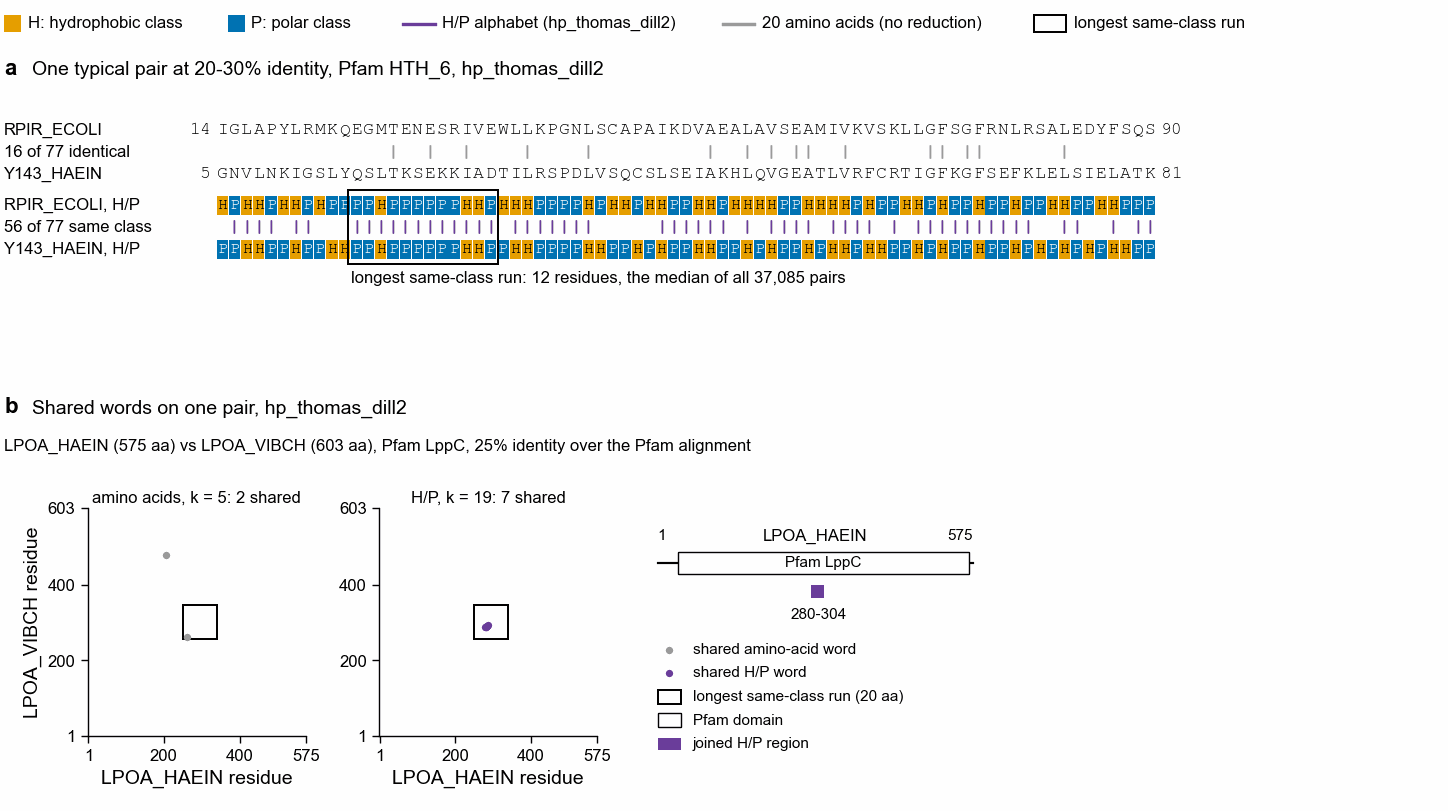

In [7]:
encode_s = lambda s: encode(s, HP_SUPP)
hp_s = pairs_all.filter(
    (pl.col("alphabet") == HP_SUPP) & (pl.col("identity_bin") == BIN)
)
hp_s_aln = hp_s.join(aln, on=["family", "query", "target"], how="inner").sort(
    "family", "query", "target"
)
median_run_s = float(hp_s["longest_run"].median())
check(
    median_run_s == int(median_run_s),
    f"median run {median_run_s} is not a whole number",
)
cand = (
    hp_s_aln.filter(pl.col("longest_run") == int(median_run_s))
    .filter(pl.col("qaln").str.len_chars() == pl.col("n_cols"))
    .filter(pl.col("n_cols") <= PANEL_A_MAX_COLS)
    .filter(
        pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
        & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean)
    )
    .with_columns(
        (pl.col("kappa") - hp_s["kappa"].mean()).abs().alias("kappa_distance")
    )
    .sort("kappa_distance", "family", "query")
)
pick = cand.row(0, named=True)
qe, te = pick["qaln"], pick["taln"]
L_e = len(qe)
qe_c, te_c = encode_s(qe), encode_s(te)
cm_e = match_line(qe_c, te_c)
runs_e = [(m.start(), m.end()) for m in re.finditer(r"\|+", cm_e)]
longest_e = max(e - s for s, e in runs_e)
longest_runs_e = [(s, e) for s, e in runs_e if e - s == longest_e]
qname, qs_e, _ = seed_coords(pick["query"])
tname, ts_e, _ = seed_coords(pick["target"])
n_ident_e, n_same_e = match_line(qe, te).count("|"), cm_e.count("|")
check(
    longest_e == pick["longest_run"] == median_run_s, "longest run differs from 230's"
)
check(abs(n_same_e / L_e - pick["agree"]) < 1e-9, "class agreement differs from 230's")
print(
    f"typical pair: {pick['query']} / {pick['target']} (Pfam {pick['family_id']}), {L_e} positions, "
    f"{n_ident_e} identical, {n_same_e} same class, longest run {longest_e} (bin median); {cand.height} candidates"
)

K_AA = math.ceil(K_SUPP * bits[HP_SUPP]["b_alpha"] / b_aa)


def shared_kmers(a: str, b: str, k: int) -> np.ndarray:
    """Every (start in a, start in b) of a word of length k the two strings share, 1-based."""
    words_b = {}
    for j in range(len(b) - k + 1):
        words_b.setdefault(b[j : j + k], []).append(j)
    out = [
        (i + 1, j + 1)
        for i in range(len(a) - k + 1)
        for j in words_b.get(a[i : i + k], [])
    ]
    return np.array(out, dtype=np.int64).reshape(-1, 2)


def join_regions(shared: np.ndarray, k: int) -> list[tuple[int, int, int, int]]:
    """Shared k-mers that overlap on one diagonal joined into regions: (a_start, a_end, b_start, b_end), 1-based."""
    regions = []
    for d in sorted(set(shared[:, 0] - shared[:, 1])):
        starts = np.sort(shared[shared[:, 0] - shared[:, 1] == d, 0])
        breaks = np.flatnonzero(np.diff(starts) > 1)
        for s, e in zip(
            np.r_[starts[0], starts[breaks + 1]], np.r_[starts[breaks], starts[-1]]
        ):
            regions.append((int(s), int(e + k - 1), int(s - d), int(e + k - 1 - d)))
    return regions


def longest_run_residues(
    qaln: str, taln: str, q_start: int, t_start: int
) -> tuple[int, int, int]:
    """Length and 1-based residue starts of the first longest same-class run in a gapped alignment."""
    qi, ti, cur, best = q_start, t_start, 0, (0, 0, 0)
    for a, b in zip(qaln, taln):
        ga, gb = a.isalpha(), b.isalpha()
        if ga and gb and TO_CLASS[HP_SUPP][a.upper()] == TO_CLASS[HP_SUPP][b.upper()]:
            cur += 1
            if cur > best[0]:
                best = (cur, qi - cur + 1, ti - cur + 1)
        else:
            cur = 0
        qi += ga
        ti += gb
    return best


rows = []
for r in cand_pairs.iter_rows(named=True):
    qn, qs0, _ = seed_coords(r["query"])
    tn, ts0, _ = seed_coords(r["target"])
    if qn not in sprot_seqs or tn not in sprot_seqs:
        continue
    q_seq, t_seq = sprot_seqs[qn], sprot_seqs[tn]
    if max(len(q_seq), len(t_seq)) > METHOD_MAX_LEN or set(q_seq + t_seq) - set(
        STANDARD
    ):
        continue
    seed_q = re.sub(r"[^A-Za-z]", "", r["qaln"]).upper()
    seed_t = re.sub(r"[^A-Za-z]", "", r["taln"]).upper()
    if (
        q_seq[qs0 - 1 : qs0 - 1 + len(seed_q)] != seed_q
        or t_seq[ts0 - 1 : ts0 - 1 + len(seed_t)] != seed_t
    ):
        continue  # seed sequence differs from Swiss-Prot 2026_03
    run_len, q_run, t_run = longest_run_residues(r["qaln"], r["taln"], qs0, ts0)
    check(
        run_len == r["longest_run"],
        f"{r['query']}: run {run_len}, 230 says {r['longest_run']}",
    )
    q_r, t_r = (
        q_seq[q_run - 1 : q_run - 1 + run_len],
        t_seq[t_run - 1 : t_run - 1 + run_len],
    )
    hp_shared = shared_kmers(encode_s(q_seq), encode_s(t_seq), K_SUPP)
    on_diag = hp_shared[:, 0] - hp_shared[:, 1] == q_run - t_run
    rows.append(
        {
            "family": r["family"],
            "family_id": r["family_id"],
            "query": r["query"],
            "target": r["target"],
            "q_len": len(q_seq),
            "t_len": len(t_seq),
            "seqid_ali": r["seqid_ali"],
            "run": run_len,
            "q_run": q_run,
            "t_run": t_run,
            "run_identity": sum(a == b for a, b in zip(q_r, t_r)) / run_len,
            "run_top_residue": max(q_r.count(c) for c in set(q_r)) / run_len,
            "run_h_share": encode_s(q_r).count("H") / run_len,
            "hp_19mers_on_diag": int(on_diag.sum()),
            "hp_19mers_off_diag": int((~on_diag).sum()),
        }
    )
method_pass = (
    pl.DataFrame(rows)
    .filter(
        (pl.col("run_top_residue") <= METHOD_MAX_TOP)
        & pl.col("run_h_share").is_between(*METHOD_H_RANGE)
        & (pl.col("run_identity") <= METHOD_MAX_IDENT)
    )
    .sort("hp_19mers_off_diag", "run_identity", "family", "query")
)
mp = method_pass.row(0, named=True)
mq_name, mt_name = mp["query"].split("/")[0], mp["target"].split("/")[0]
mq, mt = sprot_seqs[mq_name], sprot_seqs[mt_name]
_, mq_dom0, mq_dom1 = seed_coords(mp["query"])
m_hp = shared_kmers(encode_s(mq), encode_s(mt), K_SUPP)
m_aa = shared_kmers(mq, mt, K_AA)
m_diag = mp["q_run"] - mp["t_run"]
m_regions = [r for r in join_regions(m_hp, K_SUPP) if r[0] - r[2] == m_diag]
m_aa_on_diag = int((m_aa[:, 0] - m_aa[:, 1] == m_diag).sum()) if len(m_aa) else 0
mq_run = mq[mp["q_run"] - 1 : mp["q_run"] - 1 + mp["run"]]
mt_run = mt[mp["t_run"] - 1 : mp["t_run"] - 1 + mp["run"]]
m_run_ident = match_line(mq_run, mt_run).count("|")
check(
    len(m_regions) == 1,
    f"{len(m_regions)} H/P regions on the run's diagonal; the caption describes one",
)
mr0, mr1, mr_t0, mr_t1 = m_regions[0]
check(
    encode_s(mq[mr0 - 1 : mr1]) == encode_s(mt[mr_t0 - 1 : mr_t1]),
    "the joined region is not all same class",
)
print(
    f"dot-plot pair: {mq_name} ({len(mq)} aa) vs {mt_name} ({len(mt)} aa), Pfam {mp['family_id']}, "
    f"{100 * mp['seqid_ali']:.1f}% identity; shared H/P {K_SUPP}-mers {len(m_hp)}, amino-acid {K_AA}-mers {len(m_aa)} "
    f"({m_aa_on_diag} on the run's diagonal); region {mq_name} {mr0}-{mr1} with {mt_name} {mr_t0}-{mr_t1}; "
    f"{method_pass.height} pairs passed the rule"
)

PITCH_A = 1.55
X_SEQ_A = 27


def draw_supp_pair(cv, ox, oy, letter):
    """The median pair, residues and H/P classes, longest same-class run boxed."""
    cv.title(
        ox,
        oy + 36,
        letter,
        f"One typical pair at {BIN} identity, Pfam {pick['family_id']}, {HP_SUPP}",
    )
    rows_, _, _ = draw_pair_block(
        cv,
        ox,
        ox + X_SEQ_A,
        oy + 29,
        PITCH_A,
        (qname, tname),
        (qs_e, ts_e),
        (qe, te),
        (qe_c, te_c),
        outline=longest_runs_e,
    )
    s, e = longest_runs_e[0]
    cv.text(
        ox + X_SEQ_A + s * PITCH_A,
        rows_["tc"] - 3.6,
        f"longest same-class run: {e - s} residues, the median of all {n_pairs:,} pairs",
        fontsize=6,
    )


def dotplot(ax, pts, color, title):
    ax.scatter(pts[:, 0], pts[:, 1], s=7, color=color, linewidths=0, zorder=3)
    pad = 35
    ax.add_patch(
        Rectangle(
            (mp["q_run"] - pad, mp["t_run"] - pad),
            mp["run"] + 2 * pad,
            mp["run"] + 2 * pad,
            fill=False,
            lw=0.7,
            ec="black",
        )
    )
    ax.set_xlim(0, len(mq))
    ax.set_ylim(0, len(mt))
    ax.set_xticks([1, 200, 400, len(mq)])
    ax.set_yticks([1, 200, 400, len(mt)])
    ax.set_aspect("equal")
    ax.set_xlabel(f"{mq_name} residue")
    ax.set_title(title, fontsize=6, pad=2)


def draw_supp_dotplots(cv, ox, oy, letter):
    """Amino-acid and H/P dot plots of one pair, and the joined H/P region on the protein."""
    cv.title(ox, oy + 50, letter, f"Shared words on one pair, {HP_SUPP}")
    cv.text(
        ox,
        oy + 45.8,
        f"{mq_name} ({len(mq)} aa) vs {mt_name} ({len(mt)} aa), Pfam {mp['family_id']}, "
        f"{100 * mp['seqid_ali']:.0f}% identity over the Pfam alignment",
        fontsize=6,
    )
    ax1 = cv.axes(ox + 10, oy + 9, 29, 29)
    dotplot(ax1, m_aa, C_AA, f"amino acids, k = {K_AA}: {len(m_aa)} shared")
    ax1.set_ylabel(f"{mt_name} residue")
    ax2 = cv.axes(ox + 47, oy + 9, 29, 29)
    dotplot(ax2, m_hp, C_HP, f"H/P, k = {K_SUPP}: {len(m_hp)} shared")
    x4, wd = ox + 83, 40.0
    sx = lambda r: x4 + (r - 1) / (len(mq) - 1) * wd
    y = oy + 31
    cv.text((sx(1) + sx(len(mq))) / 2, y + 3.4, mq_name, fontsize=6, ha="center")
    cv.text(sx(1), y + 3.4, "1", fontsize=5.5)
    cv.text(sx(len(mq)), y + 3.4, f"{len(mq)}", fontsize=5.5, ha="right")
    cv.line([sx(1), sx(len(mq))], [y, y], color="black", lw=0.8)
    cv.rect(
        sx(mq_dom0),
        y - 1.4,
        sx(mq_dom1) - sx(mq_dom0),
        2.8,
        facecolor="white",
        edgecolor="black",
        lw=0.5,
        zorder=3,
    )
    cv.text(
        (sx(mq_dom0) + sx(mq_dom1)) / 2,
        y,
        f"Pfam {mp['family_id']}",
        fontsize=5.5,
        ha="center",
        zorder=4,
    )
    for a, b, _, _ in m_regions:
        cv.rect(
            sx(a),
            y - 4.4,
            max(sx(b) - sx(a), 0.6),
            1.6,
            facecolor=C_HP,
            edgecolor="none",
        )
    run_x = (sx(mp["q_run"]) + sx(mp["q_run"] + mp["run"] - 1)) / 2
    cv.text(
        run_x,
        y - 6.6,
        ", ".join(f"{a}-{b}" for a, b, _, _ in m_regions),
        fontsize=5.5,
        ha="center",
    )
    keys = [
        ("dot_aa", "shared amino-acid word"),
        ("dot_hp", "shared H/P word"),
        ("box", f"longest same-class run ({mp['run']} aa)"),
        ("dom", "Pfam domain"),
        ("bar", "joined H/P region"),
    ]
    for n, (kind, label) in enumerate(keys):
        yy = oy + 20 - n * 3.0
        if kind.startswith("dot"):
            cv.ax.scatter(
                [x4 + 1.5],
                [yy],
                s=7,
                color=C_AA if kind == "dot_aa" else C_HP,
                linewidths=0,
            )
        elif kind == "box":
            cv.rect(x4, yy - 0.9, 3.0, 1.8, facecolor="none", edgecolor="black", lw=0.7)
        elif kind == "dom":
            cv.rect(
                x4, yy - 0.9, 3.0, 1.8, facecolor="white", edgecolor="black", lw=0.5
            )
        else:
            cv.rect(x4, yy - 0.8, 3.0, 1.6, facecolor=C_HP, edgecolor="none")
        cv.text(x4 + 4.5, yy, label, fontsize=5.5)
    return ax1, ax2


def legend_row(cv, items, y, x=0):
    """One key row: (kind, colour, label); kind is sq (class square), ln (line), box (outline), band (shaded k range)."""
    for kind, color, label in items:
        if kind == "sq":
            cv.rect(x, y - 1.1, 2.2, 2.2, facecolor=color, edgecolor="none")
            dx = 3
        elif kind == "box":
            cv.rect(x, y - 1.1, 4, 2.2, facecolor="none", edgecolor=color, lw=0.7)
            dx = 5
        elif kind == "band":
            cv.rect(x, y - 1.3, 4, 2.6, facecolor=color, alpha=0.35, edgecolor="none")
            dx = 5
        else:
            cv.line([x, x + 4], [y, y], color=color, lw=1.2)
            dx = 5
        t = cv.text(x + dx, y, label, fontsize=6)
        x += dx + 1.02 * len(label) + 5
    return x


cv = Canvas(pf.TWO_COLUMN_MM, 102)
legend_row(
    cv,
    [
        ("sq", C_H, "H: hydrophobic class"),
        ("sq", C_P, "P: polar class"),
        ("ln", C_HP, f"H/P alphabet ({HP_SUPP})"),
        ("ln", C_AA, "20 amino acids (no reduction)"),
        ("box", "black", "longest same-class run"),
    ],
    y=102 - 2.5,
)
draw_supp_pair(cv, 0, 57, "a")
draw_supp_dotplots(cv, 0, 0, "b")
SUPP = "figS_fig1_hp_thomas_dill2_pair_and_dotplots"
cv.fig.savefig(FIG / f"{SUPP}.pdf")
save_png(cv.fig, FIG / f"{SUPP}.png")

## 7. Helix, strand and coil: is secondary structure available for the seed pairs?

Pfam stores secondary structure as `#=GR <sequence> SS` lines. The cell counts every
per-sequence (`#=GR`) and per-column (`#=GC`) annotation type in the Pfam-A 38.2 seed.

In [8]:
ann_counts = {}
with gzip.open(PFAM_SEED, "rb") as fh:
    for line in fh:
        if line.startswith(b"#=GR ") or line.startswith(b"#=GC "):
            parts = line.split()
            key = (
                parts[0].decode(),
                (parts[2] if parts[0] == b"#=GR" else parts[1]).decode(),
            )
            ann_counts[key] = ann_counts.get(key, 0) + 1
n_ss = sum(v for (kind, tag), v in ann_counts.items() if tag in ("SS", "SS_cons"))
print(
    "annotation lines in Pfam-A 38.2 seed: "
    + "; ".join(f"{k} {t}: {v:,}" for (k, t), v in sorted(ann_counts.items()))
)
print(f"secondary-structure lines (SS or SS_cons): {n_ss}")

annotation lines in Pfam-A 38.2 seed: #=GC RF: 111; #=GC seq_cons: 30,134; #=GR AS: 658; #=GR pAS: 67,854; #=GR sAS: 13,398
secondary-structure lines (SS or SS_cons): 0


The seed file has no secondary-structure lines, so a helix, strand and coil split cannot be made
from the seed alignments. It would need structures mapped onto each seed sequence (PDB or
AlphaFold, then DSSP).

## 8. Figure 1 and the Figure 3 draft

183 mm wide (two Nature columns). Arial for text and Courier New for sequences, embedded as
TrueType so the text stays editable; PNGs with a 256-colour palette. Colour says which alphabet
and shape says what the mark is: amber and blue squares are the h and p classes, purple is
`hp_lehninger2`, grey the 20 amino acids, the yellow band the k-mer sizes kmerseek tests.

fig1.pdf fonts: ['EUPZFS+CourierNewPSMT', 'GOFYPY+Arial-BoldMT', 'GOFYPY+ArialMT', 'PEPWNA+CourierNewPS-BoldMT'] | TrueType: True
figS_fig1_hp_thomas_dill2_pair_and_dotplots.pdf fonts: ['EUPZFS+CourierNewPSMT', 'GOFYPY+Arial-BoldMT', 'GOFYPY+ArialMT', 'PEPWNA+CourierNewPS-BoldMT'] | TrueType: True
fig3_draft_hp_run_length_pfam_a_38.2_seed_20-30pct.pdf fonts: ['GOFYPY+ArialMT'] | TrueType: True


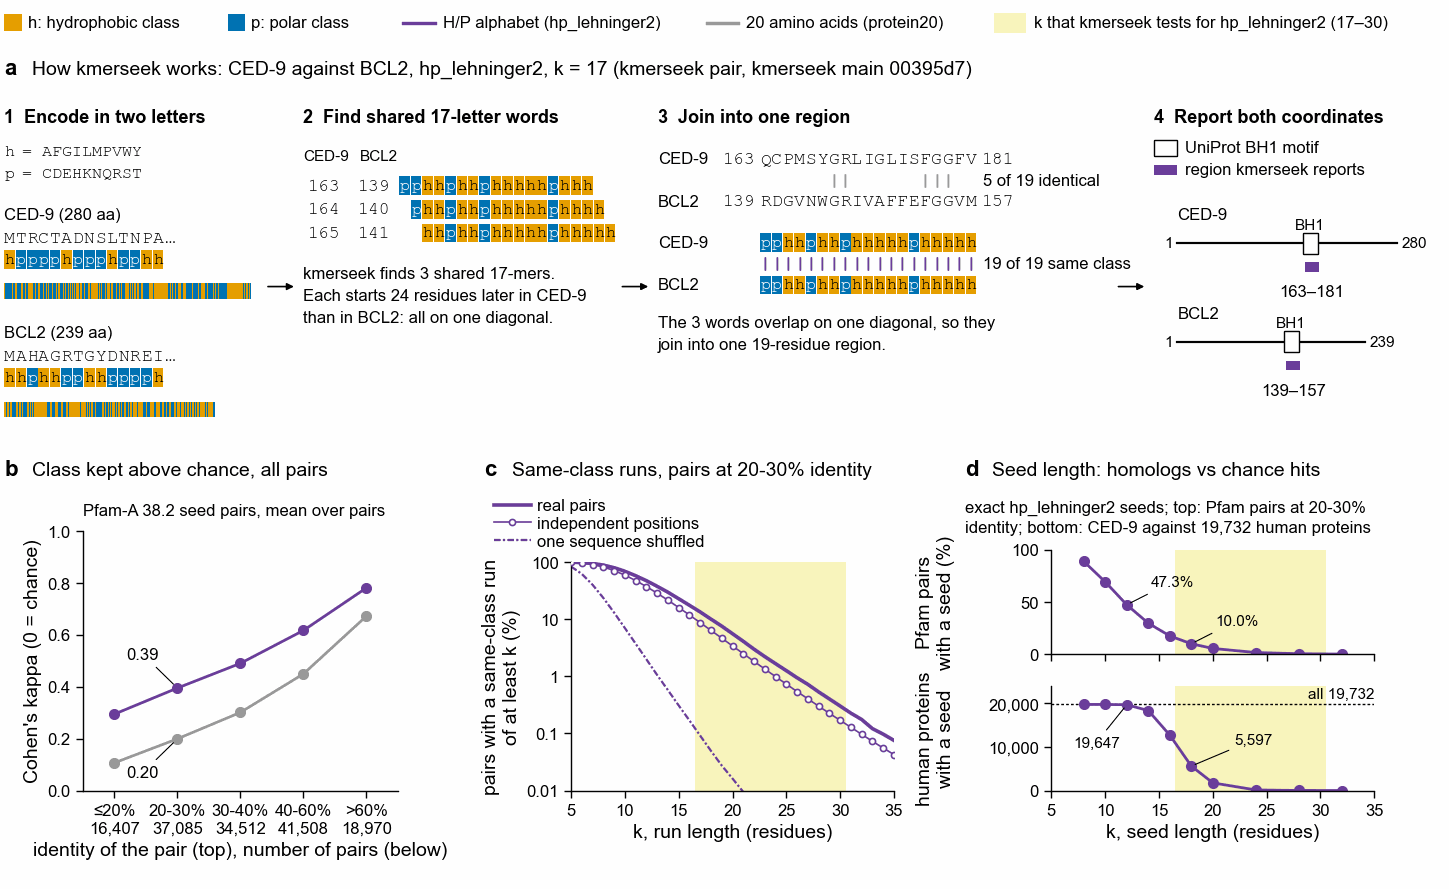

In [9]:
W, H = pf.TWO_COLUMN_MM, 112
cv = Canvas(W, H)
legend_row(
    cv,
    [
        ("sq", C_H, "h: hydrophobic class"),
        ("sq", C_P, "p: polar class"),
        ("ln", C_HP, f"H/P alphabet ({HP})"),
        ("ln", C_AA, "20 amino acids (protein20)"),
        ("band", C_KRANGE, f"k that kmerseek tests for {HP} ({k_min}–{k_max})"),
    ],
    y=H - 2.5,
)
draw_panel_a(cv, 0, 56)
draw_panel_b(cv, 0, 2)
draw_panel_c(cv, 61, 2)
draw_panel_d(cv, 122, 2)
cv.fig.savefig(FIG / "fig1.pdf")
save_png(cv.fig, FIG / "fig1.png")
fig1_fig = cv.fig


for path in (FIG / "fig1.pdf", FIG / f"{SUPP}.pdf", FIG / f"{FIG3}.pdf"):
    fonts = sorted(set(re.findall(rb"/BaseFont /([A-Za-z0-9+_-]+)", path.read_bytes())))
    print(
        path.name,
        "fonts:",
        [f.decode() for f in fonts],
        "| TrueType:",
        b"/FontFile2" in path.read_bytes(),
    )
    check(
        not any(b"DejaVu" in f for f in fonts),
        f"a DejaVu fallback font is in {path.name}",
    )

## 9. Text that overlaps or leaves the canvas

Every text label of Figure 1 is measured on the rendered figure: its box must lie inside the
canvas and must not overlap another label's box. Labels that belong together on purpose (a class
letter inside its square) are not text-on-text, so only text boxes are compared.

In [10]:
fig1_fig.canvas.draw()
renderer = fig1_fig.canvas.get_renderer()
fig_box = fig1_fig.bbox
boxes = []
for t in fig1_fig.findobj(mpl.text.Text):
    if not t.get_visible() or not t.get_text().strip():
        continue
    bb = t.get_window_extent(renderer)
    boxes.append((t.get_text(), bb))
outside = [
    s
    for s, bb in boxes
    if bb.x0 < fig_box.x0 - 0.5
    or bb.x1 > fig_box.x1 + 0.5
    or bb.y0 < fig_box.y0 - 0.5
    or bb.y1 > fig_box.y1 + 0.5
]
overlaps = []
for i in range(len(boxes)):
    for j in range(i + 1, len(boxes)):
        a, b = boxes[i][1], boxes[j][1]
        ox_ = min(a.x1, b.x1) - max(a.x0, b.x0)
        oy_ = min(a.y1, b.y1) - max(a.y0, b.y0)
        if ox_ > 0.5 and oy_ > 0.5:
            overlaps.append((boxes[i][0], boxes[j][0], round(ox_, 1), round(oy_, 1)))
print(f"{len(boxes)} text labels measured; off the canvas: {outside}")
print(f"overlapping pairs: {len(overlaps)}")
for o in overlaps:
    print("  ", o)
check(not outside, f"text off the canvas: {outside}")
check(not overlaps, f"{len(overlaps)} overlapping text pairs")

323 text labels measured; off the canvas: []
overlapping pairs: 0


## 10. Captions and the values behind them

Every number in the captions is formatted from a variable computed above; the same values are in
`figures/fig1_values.json`.

In [11]:
values = {
    "pfam_release": "Pfam-A 38.2 seed",
    "identity_bin": BIN,
    "min_aligned_positions": MIN_COLS,
    "alphabet": HP,
    "alphabet_classes": {"h": H_RES, "p": P_RES},
    "n_pairs": n_pairs,
    "n_families": hp["family"].n_unique(),
    "fig1a": {
        "kmerseek_commit": KMERSEEK_COMMIT,
        "kmerseek_version": provenance["kmerseek_version"],
        "k": K_PAIR,
        "query": "CED-9 (P41958)",
        "target": "BCL2 (P10415)",
        "query_length": LEN["CED-9"],
        "target_length": LEN["BCL2"],
        "n_shared_kmers": len(words),
        "n_regions": len(pair["regions"]),
        "shared_kmers_1based": [
            {"ced9": w["query_pos"] + 1, "bcl2": w["target_pos"] + 1, "hp": w["kmer"]}
            for w in words
        ],
        "diagonal_offset": pair_offset,
        "ced9_region": list(ced9_r),
        "bcl2_region": list(bcl2_r),
        "region_length": region_len,
        "identical": pair_identical,
        "same_class": pair_same,
        "ced9_region_residues": ced9_reg,
        "bcl2_region_residues": bcl2_reg,
        "uniprot_release": "2026_03",
        "ced9_bh1": list(ced9_bh1),
        "bcl2_bh1": list(bcl2_bh1),
        "ced9_region_in_bh1": overlap(ced9_bh1, ced9_r),
        "bcl2_region_in_bh1": overlap(bcl2_bh1, bcl2_r),
    },
    "fig1b": [
        {
            **{
                k: r[k]
                for k in ("alphabet", "n_pairs", "kappa", "kappa_lo", "kappa_hi")
            },
            "identity_bin": BIN_SHOWN[r["identity_bin"]],
        }
        for r in kappa_bins.iter_rows(named=True)
        if r["alphabet"] != HP_SUPP
    ],
    "fig1b_identity_bins": "each bin includes its upper edge: ≤20% is 0-20%, 20-30% is above 20% up to 30%",
    "fig1b_hp_over_aa_kappa": {BIN_SHOWN[b]: v for b, v in ratio_by_bin.items()},
    "fig1c": {
        "n_shuffles": N_SHUFFLE,
        "mean_pr_agree": mean_pr_agree,
        "mean_longest_run_real": mean_run,
        "median_longest_run_real": median_run,
        "mean_longest_run_shuffled": mean_run_null,
        "first_k_real_above_predicted": first_above,
        "real_over_predicted_k17_to_35": [ratio_lo, ratio_hi],
        "real_over_one_stretch_k17_to_35": [one_lo, one_hi],
        "share_at_k": {
            int(k): {
                "real": at(share_real, k),
                "predicted": at(share_pred, k),
                "predicted_one_stretch": at(share_pred_one, k),
                "shuffled": at(share_null, k),
            }
            for k in KS
        },
    },
    "fig1d": {
        "source": f"PR 113 tables at {SEEDS_COMMIT[:7]}, exact seeds",
        "n_pfam_pairs": n_pairs_seed,
        "n_human_proteins": N_HUMAN,
        "k_min": k_min,
        "k_max": k_max,
        "ksizes_source": f"PR 101 table at {KSIZES_COMMIT[:7]}",
        "by_k": {
            int(k): {
                "pfam_share_with_seed": seed_share[k],
                "human_proteins_with_seed": seed_human[k],
            }
            for k in seed_k
        },
    },
    "kstar": {"swissprot": "2026_03", **{a: d for a, d in bits.items()}},
    "supplementary": {
        "alphabet": HP_SUPP,
        "pair": {
            "family": pick["family"],
            "family_id": pick["family_id"],
            "query": pick["query"],
            "target": pick["target"],
            "positions": L_e,
            "identical": n_ident_e,
            "same_class": n_same_e,
            "longest_run": longest_e,
            "bin_median_longest_run": median_run_s,
            "n_candidates": cand.height,
        },
        "dotplots": {
            "family": mp["family"],
            "family_id": mp["family_id"],
            "query": mp["query"],
            "target": mp["target"],
            "query_length": len(mq),
            "target_length": len(mt),
            "seqid_ali": mp["seqid_ali"],
            "run": mp["run"],
            "run_identical": m_run_ident,
            "k_hp": K_SUPP,
            "k_aa": K_AA,
            "b_aa": b_aa,
            "n_shared_hp_kmers": int(len(m_hp)),
            "n_shared_aa_kmers": int(len(m_aa)),
            "n_shared_aa_kmers_on_diagonal": m_aa_on_diag,
            "hp_region_query": [mr0, mr1],
            "hp_region_target": [mr_t0, mr_t1],
            "n_candidates": method_pass.height,
        },
    },
    "secondary_structure_lines_in_seed": n_ss,
}
(FIG / "fig1_values.json").write_text(json.dumps(values, indent=1, default=float))

hpk, aak = kc[(HP, BIN)], kc[(AA, BIN)]
lo_bin, hi_bin = hc.IDENTITY_LABELS[0], hc.IDENTITY_LABELS[-1]
bin_txt = BIN.replace("-", "–")
n_run = round(mean_run)
join3 = lambda xs: ", ".join(str(x) for x in xs[:-1]) + f" and {xs[-1]}"
starts_ced9 = join3(sorted(w["query_pos"] + 1 for w in words))
starts_bcl2 = join3(sorted(w["target_pos"] + 1 for w in words))
ov_c, ov_b = overlap(ced9_bh1, ced9_r), overlap(bcl2_bh1, bcl2_r)
bh1_overlap_txt = (
    f"{ov_c} residues each" if ov_c == ov_b else f"{ov_c} and {ov_b} residues"
)
caption1 = f"""**Figure 1 | Related proteins keep their H/P pattern in runs of about {n_run} residues, so kmerseek's seed length trades homologs reached against chance hits.**
H/P is kmerseek's {HP} alphabet in every panel: hydrophobic (h) {H_RES}, polar (p) {P_RES}. Amber and blue squares are the h and p classes; purple marks H/P and grey the 20 amino acids. Panels b, c and the top of d use pairs of sequences from the same Pfam-A 38.2 seed alignment with at least {MIN_COLS} aligned positions (no gap in either sequence, both residues one of the 20 standard amino acids).
**a**, How kmerseek works, drawn from the output of `kmerseek pair` (kmerseek main, commit {KMERSEEK_COMMIT[:7]}) on CED-9 (*Caenorhabditis elegans*, P41958, {LEN['CED-9']} aa) against human BCL2 (P10415, {LEN['BCL2']} aa) at k = {K_PAIR}. (1) Each residue is replaced by its class, h or p. (2) kmerseek finds every {K_PAIR}-letter h/p word the two proteins share. There are {len(words)}, starting at CED-9 {starts_ced9} and BCL2 {starts_bcl2}. Each starts {pair_offset} residues later in CED-9 than in BCL2, so all lie on one diagonal. (3) Words that overlap on one diagonal join into one region of {region_len} residues; {pair_identical} of {region_len} residues are identical (grey ticks) and {pair_same} of {region_len} have the same class (purple ticks). (4) kmerseek reports the region on both proteins: CED-9 {ced9_r[0]}–{ced9_r[1]} and BCL2 {bcl2_r[0]}–{bcl2_r[1]} (purple bars), which overlap the UniProt BH1 motifs (white boxes; CED-9 {ced9_bh1[0]}–{ced9_bh1[1]}, BCL2 {bcl2_bh1[0]}–{bcl2_bh1[1]}; UniProt 2026_03) by {bh1_overlap_txt}. Coordinates are 1-based and include both ends.
**b**, Cohen's kappa, mean over pairs, by percent identity (each bin includes its upper edge). Kappa is the agreement of the classes of aligned residues corrected for chance: 0 is the agreement expected from the two sequences' class shares, 1 is every aligned residue in the same class. At {bin_txt} identity ({n_pairs:,} pairs from {hp['family'].n_unique():,} families), kappa is {hpk['kappa']:.2f} for H/P and {aak['kappa']:.2f} for the 20 amino acids; 95% bootstrap intervals over pairs are {hpk['kappa_lo']:.4f}–{hpk['kappa_hi']:.4f} and {aak['kappa_lo']:.4f}–{aak['kappa_hi']:.4f}, shorter than the dots. H/P kappa is above amino-acid kappa in every bin, {ratio_by_bin[lo_bin]:.1f} times as high at {BIN_SHOWN[lo_bin]} and {ratio_by_bin[hi_bin]:.1f} times at {BIN_SHOWN[hi_bin]} identity.
**c**, Share of the {n_pairs:,} pairs at {bin_txt} identity whose longest same-class run (aligned positions in a row, no gap, same class in both) is at least k. The vertical axis is spaced by ratio: the step from 0.1% to 1% takes as much room as the step from 1% to 10%. Real pairs (solid line): the longest run averages {mean_run:.1f} residues (median {median_run:.0f}); {pct(at(share_real, k_min))} of pairs reach k = {k_min} and {pct(at(share_real, k_max))} reach k = {k_max}. Independent positions (open circles): for each pair, the exact probability of a run of at least k if each aligned position kept its class on its own, with that pair's share of same-class positions (mean {mean_pr_agree:.2f}); runs stop at alignment gaps. The curve is the mean over pairs. Real pairs are {ratio_lo:.2f}–{ratio_hi:.2f} times this at k = {K_RATIO_FROM}–{KS[-1]}. One sequence shuffled (dash-dot; {N_SHUFFLE} shuffles per pair, composition and gaps kept): the longest run averages {mean_run_null:.1f} residues and {pct(at(share_null, k_min))} of pairs reach k = {k_min}.
**d**, The seed-length trade, exact seeds (k letters in a row, no mismatch). Top, share of Pfam seed pairs at {bin_txt} identity whose own alignment diagonal holds at least one shared k-mer ({n_pairs_seed:,} pairs; this table also counts aligned positions that hold a non-standard residue, which adds one pair to b and c's {n_pairs:,}). Bottom, human proteins (one per gene, {N_HUMAN:,} in all) that share at least one k-mer with CED-9. At k = 12, {pct(seed_share[12])} of pairs share a seed and so do {seed_human[12]:,} human proteins; at k = 18, {pct(seed_share[18])} and {seed_human[18]:,}. Yellow band in c and d: the k-mer sizes kmerseek tests for {HP}, {k_min} to {k_max}.
"""
caption3 = f"""**Figure 3 (draft panel) | At {bin_txt} identity, same-class runs are longer than independent positions would give, but few reach the length an H/P seed needs.**
The {n_pairs:,} Pfam-A 38.2 seed pairs at {bin_txt} identity, {HP} (hydrophobic {H_RES}, polar {P_RES}). Top, share of pairs whose longest same-class run (aligned positions in a row, no gap, same class in both) is at least k; the vertical axis is spaced by ratio, so the step from 0.1% to 1% takes as much room as the step from 1% to 10%. Real pairs (solid line): mean longest run {mean_run:.1f} residues (median {median_run:.0f}); {pct(at(share_real, 19))} of pairs reach k = 19 and {pct(at(share_real, 30))} reach k = 30. Predicted from independent positions (open circles): for each pair, Pr(agree) is its share of aligned positions in the same class (mean {mean_pr_agree:.2f}); the curve is the mean over pairs of the exact probability of a run of at least k if each aligned position kept its class on its own with that pair's Pr(agree), runs stopping at alignment gaps. One sequence shuffled (dash-dot; {N_SHUFFLE} shuffles per pair, composition and gaps kept): mean longest run {mean_run_null:.1f}, {pct(at(share_null, 19))} of pairs reach k = 19. Bottom, real divided by predicted: {ratio_lo:.2f}–{ratio_hi:.2f} at k = {K_RATIO_FROM}–{KS[-1]} ({pct(at(share_real, 30))} against {pct(at(share_pred, 30))} at k = 30). If each pair's aligned positions are instead joined into one unbroken stretch, the prediction is higher than the real pairs (real / predicted {one_lo:.2f}–{one_hi:.2f}). Dashed line: k* = {kstar}, the H/P k-mer length at which one chance match is expected across Swiss-Prot 2026_03; k* = ⌈log2 N / B_α⌉, with N = {bits[HP]['n_res']:,} residues and B_α = −log2(h_query·h_target + p_query·p_target) = {bits[HP]['b_alpha']:.3f} bits per letter, where h_query = h_target = {bits[HP]['h']:.3f} and p_query = p_target = {bits[HP]['p']:.3f} are the Swiss-Prot hydrophobic and polar shares. {pct(at(share_real, kstar))} of real pairs reach k*. Dotted line: mean longest run of real pairs.
"""
hs, ps = hp_classes[HP_SUPP]
captionS = f"""**Supplementary Figure | The previous Figure 1's examples, in {HP_SUPP}.**
H/P is kmerseek's {HP_SUPP} alphabet in both panels: hydrophobic {hs}, polar {ps}. Amber and blue squares are the H and P classes; purple marks H/P and grey the 20 amino acids. Pairs of sequences from the same Pfam-A 38.2 seed alignment.
**a**, One pair, {qname} residues {qs_e}–{qs_e + L_e - 1} and {tname} residues {ts_e}–{ts_e + L_e - 1} (Pfam {pick['family_id']}, {pick['family']}). {n_ident_e} of {L_e} aligned residues are identical (grey ticks) and {n_same_e} of {L_e} have the same class (purple ticks). Its longest same-class run (aligned positions in a row, no gap, same class in both; black box) is {longest_e} residues, the median of all {n_pairs:,} pairs at {bin_txt} identity, which is why it was chosen.
**b**, Shared words on one pair: {mq_name} ({len(mq)} aa) and {mt_name} ({len(mt)} aa), Pfam {mp['family_id']} ({mp['family']}), {100 * mp['seqid_ali']:.0f}% identity over the Pfam alignment. Dot plots of the full Swiss-Prot sequences: each dot is a word both proteins contain, placed at its start in each. Left, amino-acid {K_AA}-mers ({len(m_aa)} shared); right, H/P {K_SUPP}-mers ({len(m_hp)} shared). The two word lengths carry about the same information in Swiss-Prot 2026_03 ({K_AA} × {b_aa:.2f} and {K_SUPP} × {bits[HP_SUPP]['b_alpha']:.2f} bits). The black box surrounds a {mp['run']}-residue same-class run in which {m_run_ident} residues are identical; {m_aa_on_diag} shared amino-acid {K_AA}-mers lie on its diagonal. The {len(m_hp)} H/P {K_SUPP}-mers overlap on that diagonal and join into one region (purple bar under {mq_name}): {mq_name} {mr0}–{mr1} with {mt_name} {mr_t0}–{mr_t1}, all {mr1 - mr0 + 1} positions in the same class, inside the Pfam domain ({mq_dom0}–{mq_dom1}). The pair was chosen by a rule: of {method_pass.height} pairs with a run of at least {K_SUPP} that is not low-complexity and at most {100 * METHOD_MAX_IDENT:.0f}% identical, the one with the fewest shared H/P {K_SUPP}-mers off that diagonal.
"""
(FIG / "fig1_caption.md").write_text(caption1)
(FIG / "fig3_draft_hp_run_length_caption.md").write_text(caption3)
(FIG / f"{SUPP}_caption.md").write_text(captionS)
print(caption1)
print(caption3)
print(captionS)
for name, c in [
    ("Figure 1", caption1),
    ("Figure 3 draft", caption3),
    ("Supplementary", captionS),
]:
    print(f"{name} caption words: {len(re.sub(r'[*]', '', c).split())}")

**Figure 1 | Related proteins keep their H/P pattern in runs of about 12 residues, so kmerseek's seed length trades homologs reached against chance hits.**
H/P is kmerseek's hp_lehninger2 alphabet in every panel: hydrophobic (h) AFGILMPVWY, polar (p) CDEHKNQRST. Amber and blue squares are the h and p classes; purple marks H/P and grey the 20 amino acids. Panels b, c and the top of d use pairs of sequences from the same Pfam-A 38.2 seed alignment with at least 50 aligned positions (no gap in either sequence, both residues one of the 20 standard amino acids).
**a**, How kmerseek works, drawn from the output of `kmerseek pair` (kmerseek main, commit 00395d7) on CED-9 (*Caenorhabditis elegans*, P41958, 280 aa) against human BCL2 (P10415, 239 aa) at k = 17. (1) Each residue is replaced by its class, h or p. (2) kmerseek finds every 17-letter h/p word the two proteins share. There are 3, starting at CED-9 163, 164 and 165 and BCL2 139, 140 and 141. Each starts 24 residues later in CED-9 than

## Summary and conclusions

The numbers below are printed by the cells above and saved in `figures/fig1_values.json`; the
captions in `figures/fig1_caption.md`, `figures/figS_fig1_hp_thomas_dill2_pair_and_dotplots_caption.md`
and `figures/fig3_draft_hp_run_length_caption.md` are formatted from the same variables.

1. `kmerseek pair` (kmerseek main `00395d7`, `hp_lehninger2`, k = 17) finds 3 shared 17-mers
   between CED-9 and BCL2, all on one diagonal, and joins them into one 19-residue region,
   CED-9 163-181 against BCL2 139-157. 5 of 19 residues are identical; all 19 have the same
   class. The region overlaps the UniProt BH1 motif of each protein by 17 residues.
2. In `hp_lehninger2`, H/P kappa is above amino-acid kappa in every identity bin (Figure 1b): 0.39
   against 0.20 at 20-30% identity. Higher kappa means more of the class pattern is kept; 0 is
   chance.
3. At 20-30% identity, the longest same-class run averages 12.0 residues (median 11), against
   6.3 with one sequence shuffled. 13.4% of pairs have a run of at least 17, the shortest k
   kmerseek tests for this alphabet, and 0.30% of at least 30, the longest (Figure 1c).
4. Shorter seeds reach more homologs and more chance hits together (Figure 1d): at k = 12, 47.3%
   of Pfam pairs at 20-30% identity share a seed, and so do 19,647 of 19,732 human proteins with
   CED-9; at k = 18, 10.0% and 5,597.
5. The helix, strand and coil split was not made: the Pfam-A 38.2 seed has no secondary-structure
   lines (section 7).